## Gaussian-Beam Convolved Sky

In [97]:
import os
import glob
import inspect
import numpy as np
import matplotlib.pyplot as plt

import healpy as hp
from astropy.io import fits

import limTOD
from limTOD import generate_LSTs_deg, generate_TOD_sky
from limTOD import GDSM_sky_model
from limTOD import HPW_mapmaking

print("limTOD imported from:")
print(limTOD.__file__)

print("\nHPW_mapmaking from:")
print(inspect.getfile(HPW_mapmaking))

print("\nHPW_mapmaking.__call__ signature:")
print(inspect.signature(HPW_mapmaking.__call__))

limTOD imported from:
/Users/user/LimTOD/rhino-TODsim/limTOD/__init__.py

HPW_mapmaking from:
/Users/user/LimTOD/rhino-TODsim/limTOD/HPW_filter.py

HPW_mapmaking.__call__ signature:
(self, *, TOD_group, dtime, cutoff_freq_group=None, gain_group=None, known_injection_group=None, Tsky_prior_mean=None, Tsky_prior_inv_cov_diag=None, Tsys_other_prior_mean_group=None, Tsys_other_prior_inv_cov_group=None, noise_variance=None, regularization=1e-12, return_full_cov=False, filter_order=4, preserve_dc=False, use_high_pass=False)


In [98]:
# ============================================================
# USER SETTINGS
# ============================================================

FREQ_MHZ = 70.0

# Keep simulation and mapmaking at same low resolution first
NSIDE = 8

# Beam folder from your copied/symlinked data
#BEAM_DIR = os.path.expanduser("~/LimTOD/rhino-TODsim/data/HornDry")
BEAM_DIR = os.path.expanduser("~/LimTOD/rhino-TODsim/data/DipoleDry")

# North pole
ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H   = 0.0

START_TIME = "2026-04-01 00:00:00"

# 4 hour simulation
N_HOURS = 24
DT = 30.0
N_TIME = int(N_HOURS * 3600 / DT)

time_list = np.arange(N_TIME) * DT
time_hours = time_list / 3600.0

# Zenith pointing
azimuth_deg_list = np.zeros(N_TIME)
elevation_deg_list = np.ones(N_TIME) * 90.0

# Antenna rotation: 360 degrees per hour
selfrot_deg_list = (360.0 * time_hours) % 360.0

# Mapmaker settings
THRESHOLD = 0.05
TRUNC_FRAC = THRESHOLD

REGULARIZATION = 1e-6

# No 1/f noise in this controlled test
USE_HIGH_PASS = False
CUTOFF_FREQ = 1e-8
FILTER_ORDER = 4

# Mild prior comparison
MILD_PRIOR_SIGMA_FACTOR = 0.3

print(f"N_TIME = {N_TIME}")
print(f"Samples per rotation = {3600 / DT:.0f}")
print(f"Total rotations = {N_HOURS}")

N_TIME = 2880
Samples per rotation = 120
Total rotations = 24


Sky diagnostics:
NSIDE: 8
NPIX: 768
min: 1181.9937744140625 K
max: 20069.912109375 K
mean: 2757.6338653564453 K


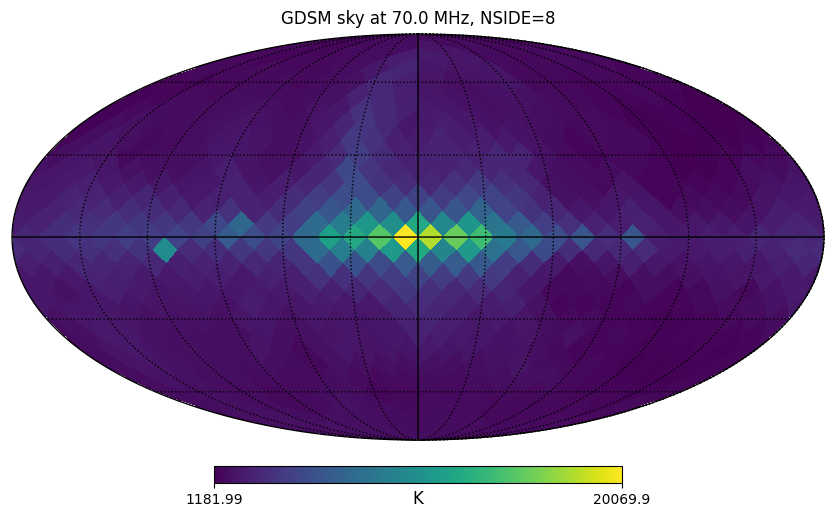

In [99]:
sky_map = GDSM_sky_model(freq=FREQ_MHZ, nside=NSIDE)
sky_map = np.asarray(sky_map, dtype=float)
sky_map = np.nan_to_num(sky_map, nan=0.0, posinf=0.0, neginf=0.0)

print("Sky diagnostics:")
print("NSIDE:", hp.npix2nside(len(sky_map)))
print("NPIX:", len(sky_map))
print("min:", np.min(sky_map), "K")
print("max:", np.max(sky_map), "K")
print("mean:", np.mean(sky_map), "K")

hp.mollview(
    sky_map,
    title=f"GDSM sky at {FREQ_MHZ:.1f} MHz, NSIDE={NSIDE}",
    unit="K",
    cmap="viridis"
)
hp.graticule()
plt.show()

Gaussian beam diagnostics
-------------------------
FWHM           : 40.00 deg
sigma          : 16.99 deg
NSIDE          : 64
NPIX           : 49152
min / max      : 6.5254e-25 / 1.0000e+00
mean           : 4.2715e-02


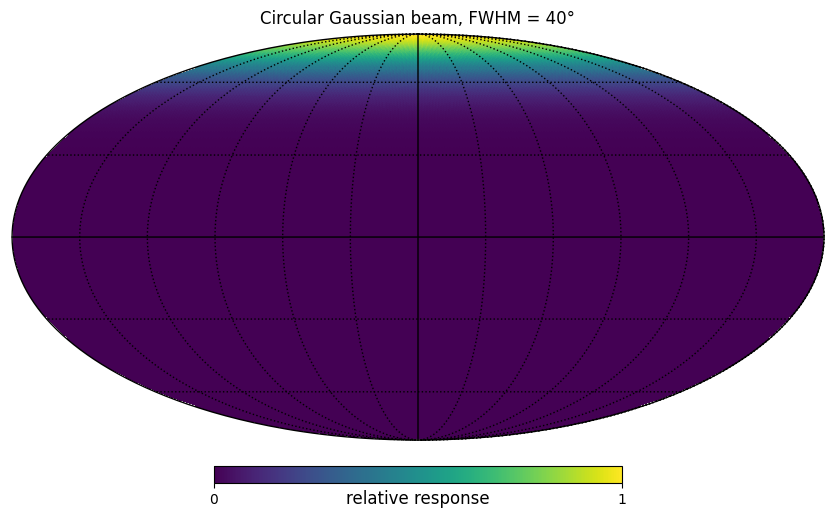

In [100]:
GAUSS_FWHM_DEG = 40.0

# Use a higher NSIDE for visualising the beam nicely
GAUSS_BEAM_NSIDE = 64

npix = hp.nside2npix(GAUSS_BEAM_NSIDE)

# HEALPix pixel directions
theta, phi = hp.pix2ang(GAUSS_BEAM_NSIDE, np.arange(npix))

# Beam centred on the north pole / zenith direction
theta0 = 0.0

# Convert FWHM to sigma
fwhm_rad = np.deg2rad(GAUSS_FWHM_DEG)
sigma_rad = fwhm_rad / np.sqrt(8.0 * np.log(2.0))

# Circular Gaussian beam
gaussian_beam = np.exp(-0.5 * (theta / sigma_rad)**2)

# Normalise peak to 1
gaussian_beam /= np.max(gaussian_beam)

NSIDE = 8

print("Gaussian beam diagnostics")
print("-------------------------")
print(f"FWHM           : {GAUSS_FWHM_DEG:.2f} deg")
print(f"sigma          : {np.rad2deg(sigma_rad):.2f} deg")
print(f"NSIDE          : {GAUSS_BEAM_NSIDE}")
print(f"NPIX           : {len(gaussian_beam)}")
print(f"min / max      : {gaussian_beam.min():.4e} / {gaussian_beam.max():.4e}")
print(f"mean           : {gaussian_beam.mean():.4e}")

hp.mollview(
    gaussian_beam,
    title=f"Circular Gaussian beam, FWHM = {GAUSS_FWHM_DEG:.0f}°",
    unit="relative response",
    min=0,
    max=1,
    cmap="viridis",
)
hp.graticule()
plt.show()

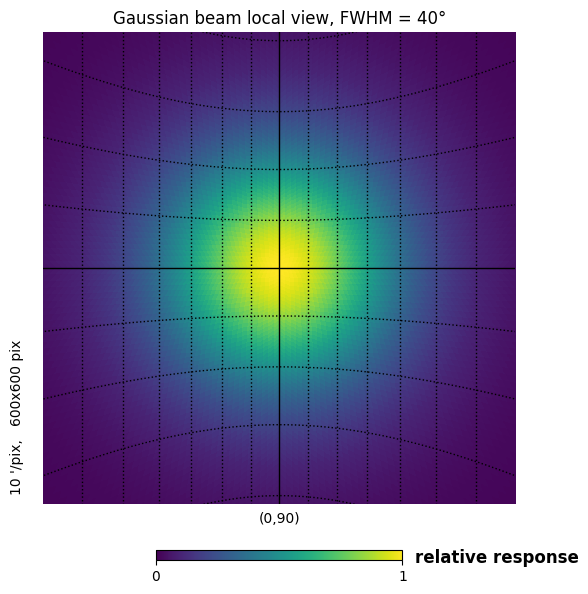

In [101]:
hp.gnomview(
    gaussian_beam,
    rot=[0, 90],          # centre view near north pole
    xsize=600,
    ysize=600,
    reso=10,              # arcmin per pixel
    title=f"Gaussian beam local view, FWHM = {GAUSS_FWHM_DEG:.0f}°",
    unit="relative response",
    min=0,
    max=1,
    cmap="viridis",
)
hp.graticule()
plt.show()

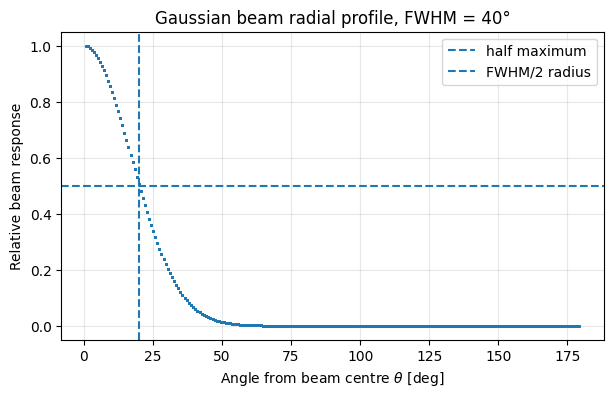

In [102]:
theta_deg = np.rad2deg(theta)

# Sort by angle from beam centre
sort_idx = np.argsort(theta_deg)

plt.figure(figsize=(7, 4))
plt.plot(theta_deg[sort_idx], gaussian_beam[sort_idx], ".", ms=2)
plt.axhline(0.5, ls="--", label="half maximum")
plt.axvline(GAUSS_FWHM_DEG / 2, ls="--", label="FWHM/2 radius")
plt.xlabel(r"Angle from beam centre $\theta$ [deg]")
plt.ylabel("Relative beam response")
plt.title(f"Gaussian beam radial profile, FWHM = {GAUSS_FWHM_DEG:.0f}°")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [103]:
# ============================================================
# Gaussian-smoothed sky reference
# ============================================================

GAUSS_FWHM_DEG = 40.0

# Smooth at a higher NSIDE first, then degrade.
# This avoids doing the convolution directly on a very coarse NSIDE=4 map.
NSIDE_SMOOTH = max(64, NSIDE)

print("Gaussian reference settings")
print("---------------------------")
print(f"Gaussian FWHM     : {GAUSS_FWHM_DEG:.1f} deg")
print(f"Smoothing NSIDE   : {NSIDE_SMOOTH}")
print(f"Final target NSIDE: {NSIDE}")

Gaussian reference settings
---------------------------
Gaussian FWHM     : 40.0 deg
Smoothing NSIDE   : 64
Final target NSIDE: 8


In [104]:
# Generate a higher-resolution sky for smoothing
sky_hi = GDSM_sky_model(freq=FREQ_MHZ, nside=NSIDE_SMOOTH)
sky_hi = np.asarray(sky_hi, dtype=float)
sky_hi = np.nan_to_num(sky_hi, nan=0.0, posinf=0.0, neginf=0.0)

print("High-resolution sky:")
print("  NSIDE:", hp.npix2nside(len(sky_hi)))
print("  min/max:", np.min(sky_hi), np.max(sky_hi))

# Convert Gaussian FWHM from degrees to radians
fwhm_rad = np.deg2rad(GAUSS_FWHM_DEG)

# Smooth with a symmetric Gaussian beam
sky_gauss_hi = hp.smoothing(
    sky_hi,
    fwhm=fwhm_rad,
)

sky_gauss_hi = np.asarray(sky_gauss_hi, dtype=float)
sky_gauss_hi = np.nan_to_num(sky_gauss_hi, nan=0.0, posinf=0.0, neginf=0.0)

# Degrade back to the simulation/mapmaking NSIDE
sky_gauss_map = hp.ud_grade(
    sky_gauss_hi,
    nside_out=NSIDE,
    power=0,
)

sky_gauss_map = np.asarray(sky_gauss_map, dtype=float)
sky_gauss_map = np.nan_to_num(sky_gauss_map, nan=0.0, posinf=0.0, neginf=0.0)

print("\nGaussian-convolved sky:")
print("  NSIDE:", hp.npix2nside(len(sky_gauss_map)))
print("  min/max:", np.min(sky_gauss_map), np.max(sky_gauss_map))
print("  mean:", np.mean(sky_gauss_map))

High-resolution sky:
  NSIDE: 64
  min/max: -9922.873046875 192826.421875

Gaussian-convolved sky:
  NSIDE: 8
  min/max: 1486.83568777205 7337.338612753785
  mean: 2757.6354613934277


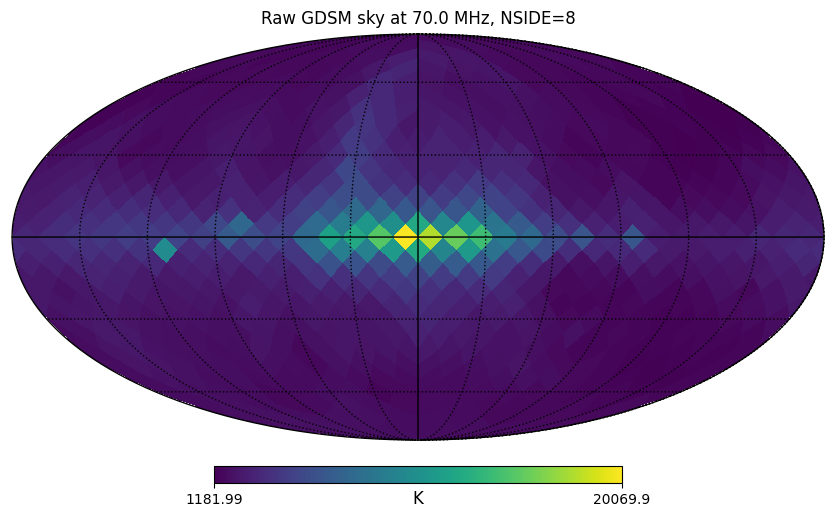

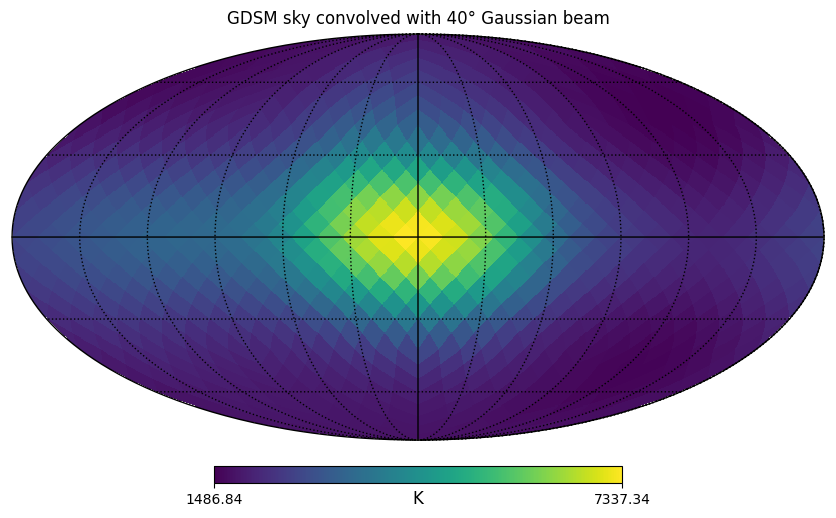

In [105]:
hp.mollview(
    sky_map,
    title=f"Raw GDSM sky at {FREQ_MHZ:.1f} MHz, NSIDE={NSIDE}",
    unit="K",
    cmap="viridis",
)
hp.graticule()
plt.show()

hp.mollview(
    sky_gauss_map,
    title=f"GDSM sky convolved with {GAUSS_FWHM_DEG:.0f}° Gaussian beam",
    unit="K",
    cmap="viridis",
)
hp.graticule()
plt.show()

## Gaussian convolved beam at nside = 64, degraded to nside = 4

In [106]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# ============================================================
# Gaussian-convolved sky reference
# ============================================================

FREQ_MHZ = 70.0

NSIDE_SMOOTH = 64   # do Gaussian convolution here
NSIDE_TARGET = 4    # degrade to this for comparison with mapmaker

GAUSS_FWHM_DEG = 40.0
GAUSS_FWHM_RAD = np.deg2rad(GAUSS_FWHM_DEG)

# ------------------------------------------------------------
# 1. Generate high-resolution sky
# ------------------------------------------------------------

sky_n64 = GDSM_sky_model(freq=FREQ_MHZ, nside=NSIDE_SMOOTH)
sky_n64 = np.asarray(sky_n64, dtype=float)
sky_n64 = np.nan_to_num(sky_n64, nan=0.0, posinf=0.0, neginf=0.0)

print("Original high-resolution sky")
print("----------------------------")
print("NSIDE:", hp.npix2nside(len(sky_n64)))
print("NPIX :", len(sky_n64))
print("min  :", np.min(sky_n64))
print("max  :", np.max(sky_n64))
print("mean :", np.mean(sky_n64))

# ------------------------------------------------------------
# 2. Convolve/smooth with 40 degree Gaussian beam
# ------------------------------------------------------------

sky_gauss_n64 = hp.smoothing(
    sky_n64,
    fwhm=GAUSS_FWHM_RAD,
    verbose=False,
)

sky_gauss_n64 = np.asarray(sky_gauss_n64, dtype=float)
sky_gauss_n64 = np.nan_to_num(sky_gauss_n64, nan=0.0, posinf=0.0, neginf=0.0)

print("\nGaussian-convolved sky at NSIDE=64")
print("----------------------------------")
print("NSIDE:", hp.npix2nside(len(sky_gauss_n64)))
print("NPIX :", len(sky_gauss_n64))
print("min  :", np.min(sky_gauss_n64))
print("max  :", np.max(sky_gauss_n64))
print("mean :", np.mean(sky_gauss_n64))

# ------------------------------------------------------------
# 3. Degrade convolved map to NSIDE=4
# ------------------------------------------------------------

sky_gauss_n4 = hp.ud_grade(
    sky_gauss_n64,
    nside_out=NSIDE_TARGET,
    power=0,
)

sky_gauss_n4 = np.asarray(sky_gauss_n4, dtype=float)
sky_gauss_n4 = np.nan_to_num(sky_gauss_n4, nan=0.0, posinf=0.0, neginf=0.0)

print("\nGaussian-convolved sky degraded to NSIDE=4")
print("------------------------------------------")
print("NSIDE:", hp.npix2nside(len(sky_gauss_n4)))
print("NPIX :", len(sky_gauss_n4))
print("min  :", np.min(sky_gauss_n4))
print("max  :", np.max(sky_gauss_n4))
print("mean :", np.mean(sky_gauss_n4))

Original high-resolution sky
----------------------------
NSIDE: 64
NPIX : 49152
min  : -9922.873046875
max  : 192826.421875
mean : 2757.633861632397

Gaussian-convolved sky at NSIDE=64
----------------------------------
NSIDE: 64
NPIX : 49152
min  : 1479.8483465436352
max  : 7387.930918309245
mean : 2757.6354613934277

Gaussian-convolved sky degraded to NSIDE=4
------------------------------------------
NSIDE: 4
NPIX : 192
min  : 1509.7421659486495
max  : 7156.134786659667
mean : 2757.6354613934272


/var/folders/y0/4z9tprvs2qb6qwgklyjc_tbw0000gp/T/ipykernel_94384/133326464.py:37: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  sky_gauss_n64 = hp.smoothing(


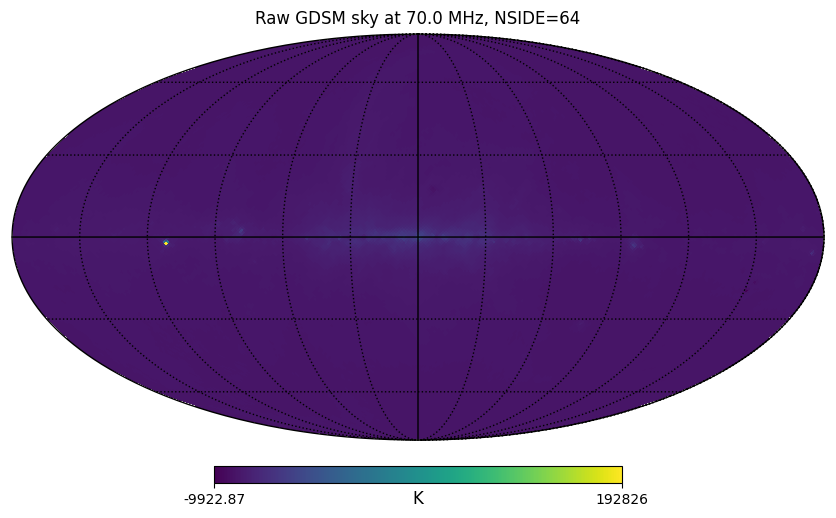

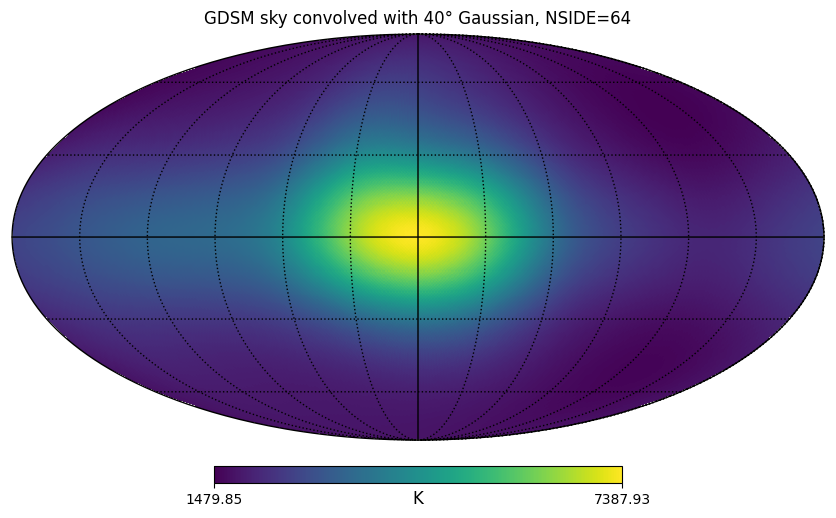

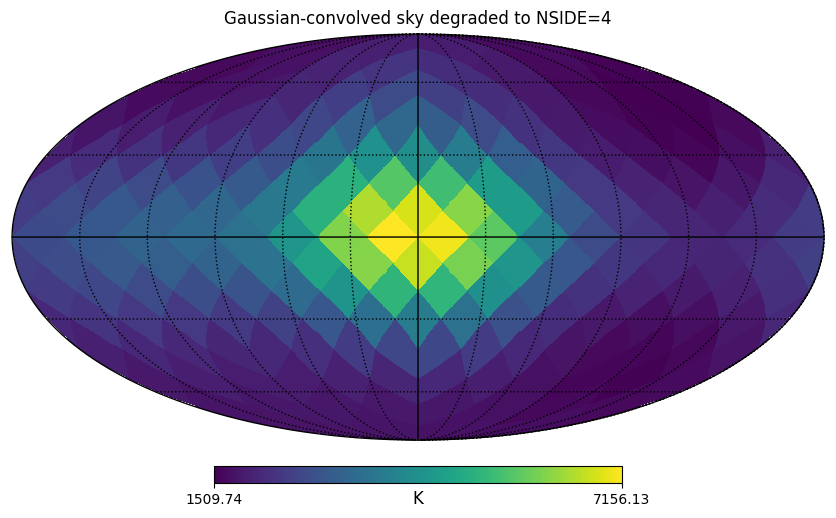

In [107]:
hp.mollview(
    sky_n64,
    title=f"Raw GDSM sky at {FREQ_MHZ:.1f} MHz, NSIDE=64",
    unit="K",
    cmap="viridis",
)
hp.graticule()
plt.show()

hp.mollview(
    sky_gauss_n64,
    title=f"GDSM sky convolved with {GAUSS_FWHM_DEG:.0f}° Gaussian, NSIDE=64",
    unit="K",
    cmap="viridis",
)
hp.graticule()
plt.show()

hp.mollview(
    sky_gauss_n4,
    title=f"Gaussian-convolved sky degraded to NSIDE=4",
    unit="K",
    cmap="viridis",
)
hp.graticule()
plt.show()

## TOD generation + Map-making

In [108]:
# ============================================================
# END-TO-END GAUSSIAN TOD + MAPMAKING PIPELINE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import inspect

from limTOD import generate_LSTs_deg, generate_TOD_sky
from limTOD import GDSM_sky_model
from limTOD import HPW_mapmaking

In [27]:
# ============================================================
# CONFIGURATION
# ============================================================

FREQ_MHZ = 70.0

# Main thing you wanted:
# simulate TOD at higher NSIDE, recover map at lower NSIDE
SIM_NSIDE = 32
MAP_NSIDE = 4

# Gaussian beam
GAUSS_FWHM_DEG = 40.0

# Observation
OBS_HOURS = 24.0
DT_SECONDS = 30.0

# Telescope location / pointing
ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H   = 0.0

AZIMUTH_DEG = 0.0
ELEVATION_DEG = 90.0   # zenith pointing

# Rotation strategy
# For a circular Gaussian this should not matter physically,
# but we keep it to test the same interface as real beams.
ROTATION_PERIOD_MIN = 60.0   # one full 360 deg rotation per hour

# Beam / mapmaker settings
NORMALIZE_BEAM_IN_TOD = True
THRESHOLD = 0.05
TRUNC_FRAC = THRESHOLD
REGULARIZATION = 1e-6

# Gaussian-smoothed truth reference settings
# Smooth at high-ish NSIDE first, then degrade to MAP_NSIDE.
NSIDE_SMOOTH = max(64, SIM_NSIDE)

print("Run configuration")
print("-----------------")
print(f"Frequency              : {FREQ_MHZ:.2f} MHz")
print(f"SIM_NSIDE              : {SIM_NSIDE}")
print(f"MAP_NSIDE              : {MAP_NSIDE}")
print(f"Gaussian FWHM          : {GAUSS_FWHM_DEG:.2f} deg")
print(f"Observation length     : {OBS_HOURS:.2f} hours")
print(f"Time step              : {DT_SECONDS:.2f} s")
print(f"Number of TOD samples  : {int(OBS_HOURS * 3600 / DT_SECONDS)}")
print(f"Normalize beam in TOD  : {NORMALIZE_BEAM_IN_TOD}")
print(f"Mapmaker threshold     : {THRESHOLD}")
print(f"Beam truncate fraction : {TRUNC_FRAC}")
print(f"Regularization         : {REGULARIZATION}")

Run configuration
-----------------
Frequency              : 70.00 MHz
SIM_NSIDE              : 32
MAP_NSIDE              : 4
Gaussian FWHM          : 40.00 deg
Observation length     : 24.00 hours
Time step              : 30.00 s
Number of TOD samples  : 2880
Normalize beam in TOD  : True
Mapmaker threshold     : 0.05
Beam truncate fraction : 0.05
Regularization         : 1e-06


In [28]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def make_gaussian_beam_healpix(nside, fwhm_deg, peak_normalize=True):
    """
    Make a circular Gaussian beam on a HEALPix sphere.

    The beam is centred on the north pole in beam/local coordinates.
    This is usually what limTOD expects for an axisymmetric beam map.

    Parameters
    ----------
    nside : int
        HEALPix NSIDE.
    fwhm_deg : float
        Gaussian full width at half maximum in degrees.
    peak_normalize : bool
        If True, divide by max beam value.

    Returns
    -------
    beam_map : ndarray
        HEALPix beam map.
    """
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix))

    sigma_rad = np.deg2rad(fwhm_deg) / np.sqrt(8.0 * np.log(2.0))

    beam_map = np.exp(-0.5 * (theta / sigma_rad) ** 2)
    beam_map = np.nan_to_num(beam_map, nan=0.0, posinf=0.0, neginf=0.0)

    if peak_normalize:
        beam_map = beam_map / np.max(beam_map)

    return beam_map


def safe_generate_TOD_sky(
    beam_map,
    sky_map,
    LST_deg_list,
    lat_deg,
    azimuth_deg_list,
    elevation_deg_list,
    selfrot_deg_list,
    nside_hires,
    normalize_beam=True,
    truncate_frac_thres=None,
):
    """
    Wrapper because different limTOD versions sometimes use slightly
    different keyword names.
    """
    kwargs = dict(
        beam_map=beam_map,
        sky_map=sky_map,
        LST_deg_list=LST_deg_list,
        azimuth_deg_list=azimuth_deg_list,
        elevation_deg_list=elevation_deg_list,
        selfrot_deg_list=selfrot_deg_list,
        nside_hires=nside_hires,
        normalize_beam=normalize_beam,
    )

    # Include truncation only if the installed version supports it.
    sig = inspect.signature(generate_TOD_sky)
    if "truncate_frac_thres" in sig.parameters and truncate_frac_thres is not None:
        kwargs["truncate_frac_thres"] = truncate_frac_thres

    if "lat_deg" in sig.parameters:
        kwargs["lat_deg"] = lat_deg
    elif "lat" in sig.parameters:
        kwargs["lat"] = lat_deg
    else:
        raise TypeError("Could not find lat/lat_deg argument in generate_TOD_sky.")

    return generate_TOD_sky(**kwargs)


def get_selected_pixels_from_mapper(mapper):
    """
    Try common attribute names used by limTOD mapmaker objects.
    """
    possible_names = [
        "pixel_indices",
        "pix",
        "selected_pixels",
        "selected_pix",
        "pix_selected",
        "nonzero_pix",
        "observed_pixels",
    ]

    for name in possible_names:
        if hasattr(mapper, name):
            pix = getattr(mapper, name)
            pix = np.asarray(pix, dtype=int)
            if pix.ndim == 1 and len(pix) > 0:
                print(f"Using mapper.{name} for selected pixels.")
                return pix

    raise AttributeError(
        "Could not automatically find selected pixels on mapper. "
        "Check dir(mapper) and look for the pixel-index attribute."
    )


def unpack_mapmaker_result(result):
    """
    Handle possible return styles from HPW_mapmaking.
    """
    if isinstance(result, tuple):
        if len(result) >= 2:
            sky_est_patch = np.asarray(result[0], dtype=float)
            sky_unc_patch = np.asarray(result[1], dtype=float)
        else:
            sky_est_patch = np.asarray(result[0], dtype=float)
            sky_unc_patch = np.full_like(sky_est_patch, np.nan, dtype=float)
    else:
        sky_est_patch = np.asarray(result, dtype=float)
        sky_unc_patch = np.full_like(sky_est_patch, np.nan, dtype=float)

    return sky_est_patch, sky_unc_patch


def patch_to_full_map(pix, values, nside, unseen=hp.UNSEEN):
    """
    Put recovered patch values back into a full HEALPix map.
    """
    full_map = np.full(hp.nside2npix(nside), unseen, dtype=float)
    full_map[np.asarray(pix, dtype=int)] = values
    return full_map


def print_map_stats(name, m):
    m = np.asarray(m, dtype=float)
    finite = np.isfinite(m)
    print(name)
    print("-" * len(name))
    print("NSIDE   :", hp.npix2nside(len(m)))
    print("NPIX    :", len(m))
    print("finite  :", np.sum(finite), "/", len(m))
    print("min/max :", np.nanmin(m[finite]), np.nanmax(m[finite]))
    print("mean/std:", np.nanmean(m[finite]), np.nanstd(m[finite]))
    print()

Observation arrays
------------------
n_tod: 2880
LST min/max: 0.07046649187578047 359.9451242333846
azimuth unique: [0.]
elevation unique: [90.]
self-rotation min/max: 0.0 357.0


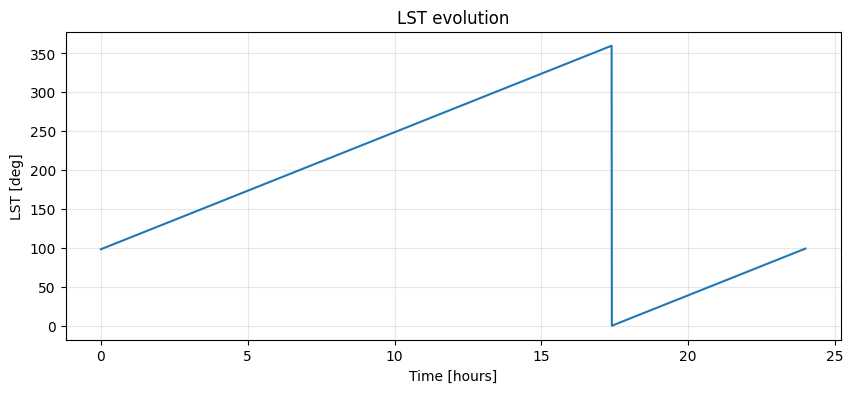

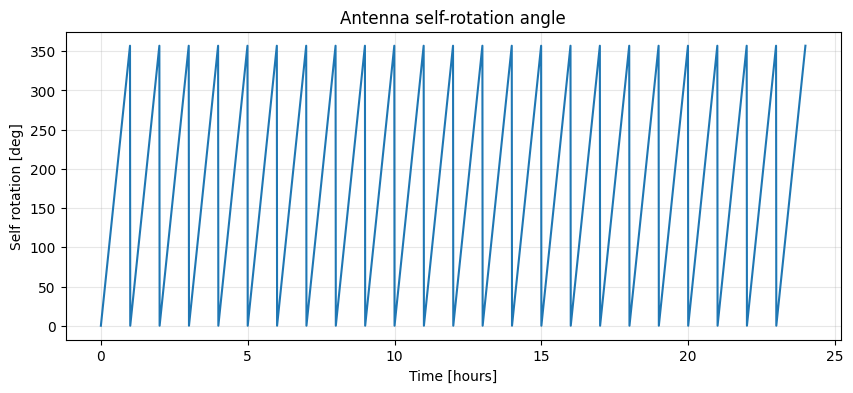

In [29]:
# ============================================================
# BUILD TIME / LST / POINTING / ROTATION ARRAYS
# ============================================================

n_tod = int(OBS_HOURS * 3600.0 / DT_SECONDS)
time_seconds = np.arange(n_tod) * DT_SECONDS
time_hours = time_seconds / 3600.0

# The actual absolute date is not important for this controlled test.
# It just anchors the LST calculation.
time_list = time_seconds

LST_deg_list = generate_LSTs_deg(
    ant_latitude_deg=ANT_LAT,
    ant_longitude_deg=ANT_LON,
    ant_height_m=ANT_H,
    time_list=time_list,
    start_time_utc="2026-01-01T00:00:00",
)

LST_deg_list = np.asarray(LST_deg_list, dtype=float)

azimuth_deg_list = np.full(n_tod, AZIMUTH_DEG, dtype=float)
elevation_deg_list = np.full(n_tod, ELEVATION_DEG, dtype=float)

rotation_period_seconds = ROTATION_PERIOD_MIN * 60.0
selfrot_deg_list = (360.0 * time_seconds / rotation_period_seconds) % 360.0

print("Observation arrays")
print("------------------")
print("n_tod:", n_tod)
print("LST min/max:", np.min(LST_deg_list), np.max(LST_deg_list))
print("azimuth unique:", np.unique(azimuth_deg_list))
print("elevation unique:", np.unique(elevation_deg_list))
print("self-rotation min/max:", np.min(selfrot_deg_list), np.max(selfrot_deg_list))

plt.figure(figsize=(10, 4))
plt.plot(time_hours, LST_deg_list, lw=1.5)
plt.xlabel("Time [hours]")
plt.ylabel("LST [deg]")
plt.title("LST evolution")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_hours, selfrot_deg_list, lw=1.5)
plt.xlabel("Time [hours]")
plt.ylabel("Self rotation [deg]")
plt.title("Antenna self-rotation angle")
plt.grid(alpha=0.3)
plt.show()

Raw GDSM simulation sky
-----------------------
NSIDE   : 32
NPIX    : 12288
finite  : 12288 / 12288
min/max : -2736.16162109375 73141.6484375
mean/std: 2757.6338613828025 2209.2382783614494



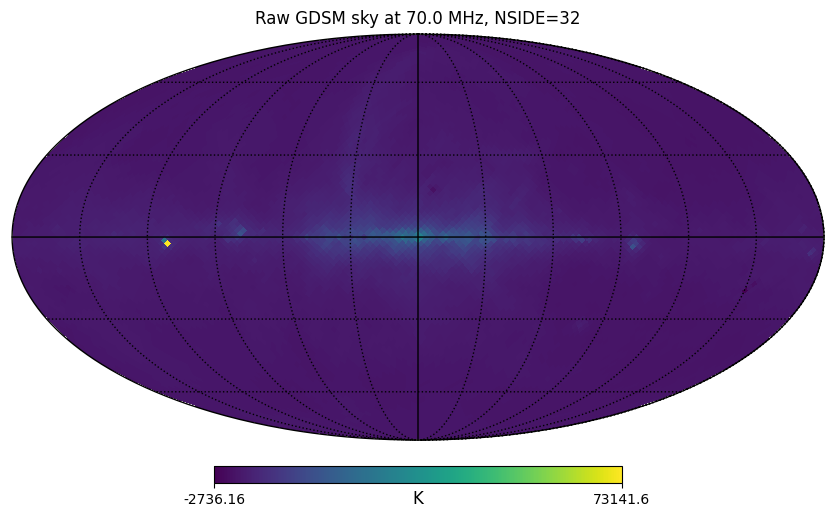

In [30]:
# ============================================================
# LOAD / GENERATE SKY AT SIMULATION RESOLUTION
# ============================================================

sky_map = GDSM_sky_model(
    freq=FREQ_MHZ,
    nside=SIM_NSIDE,
)

sky_map = np.asarray(sky_map, dtype=float)
sky_map = np.nan_to_num(sky_map, nan=0.0, posinf=0.0, neginf=0.0)

print_map_stats("Raw GDSM simulation sky", sky_map)

hp.mollview(
    sky_map,
    title=f"Raw GDSM sky at {FREQ_MHZ:.1f} MHz, NSIDE={SIM_NSIDE}",
    unit="K",
    cmap="viridis",
)
hp.graticule()
plt.show()

Gaussian beam map
-----------------
NSIDE   : 32
NPIX    : 12288
finite  : 12288 / 12288
min/max : 1.0295745688916673e-24 1.0
mean/std: 0.04281341942858549 0.1412625069956807

Gaussian beam diagnostics
-------------------------
Peak-normalized beam sum over pixels: 526.0912979384585
Pixel-area weighted beam integral [sr]: 0.5380092958076108
Full sky solid angle [sr]: 12.566370614359172


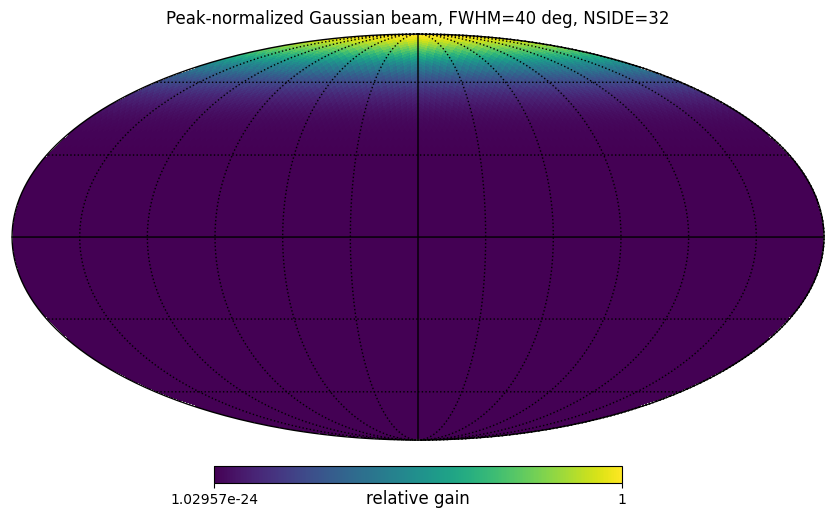

In [31]:
# ============================================================
# MAKE GAUSSIAN BEAM AT SIMULATION RESOLUTION
# ============================================================

beam_map = make_gaussian_beam_healpix(
    nside=SIM_NSIDE,
    fwhm_deg=GAUSS_FWHM_DEG,
    peak_normalize=True,
)

beam_sum = np.sum(beam_map)
beam_solid_angle_pix = beam_sum * hp.nside2pixarea(SIM_NSIDE)

print_map_stats("Gaussian beam map", beam_map)
print("Gaussian beam diagnostics")
print("-------------------------")
print("Peak-normalized beam sum over pixels:", beam_sum)
print("Pixel-area weighted beam integral [sr]:", beam_solid_angle_pix)
print("Full sky solid angle [sr]:", 4.0 * np.pi)

hp.mollview(
    beam_map,
    title=f"Peak-normalized Gaussian beam, FWHM={GAUSS_FWHM_DEG:.0f} deg, NSIDE={SIM_NSIDE}",
    unit="relative gain",
    cmap="viridis",
)
hp.graticule()
plt.show()

Gaussian-smoothed truth map
---------------------------
NSIDE   : 4
NPIX    : 192
finite  : 192 / 192
min/max : 1509.7421659486495 7156.134786659667
mean/std: 2757.6354613934272 1234.225492573361



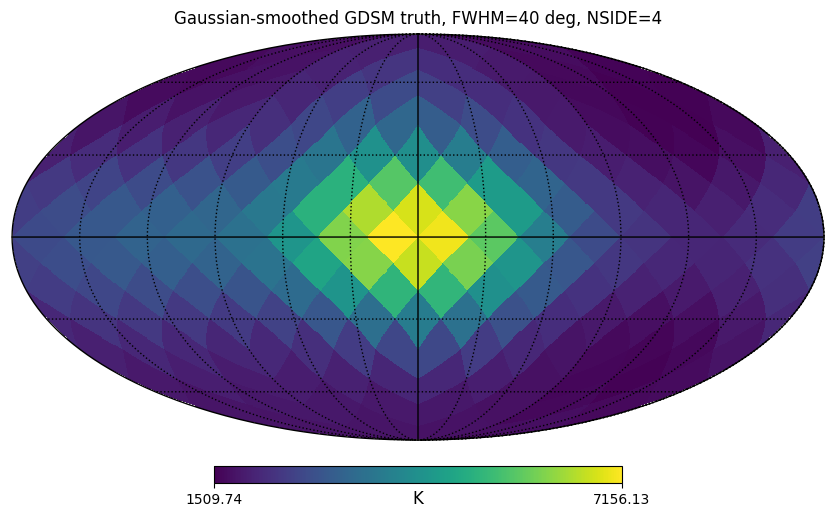

In [32]:
# ============================================================
# MAKE GAUSSIAN-SMOOTHED TRUTH / REFERENCE MAP
# ============================================================
#
# This is the truth you said you want:
# not raw GDSM degraded directly,
# but GDSM smoothed with a 40 degree Gaussian beam,
# then degraded to MAP_NSIDE.

sky_hi = GDSM_sky_model(
    freq=FREQ_MHZ,
    nside=NSIDE_SMOOTH,
)

sky_hi = np.asarray(sky_hi, dtype=float)
sky_hi = np.nan_to_num(sky_hi, nan=0.0, posinf=0.0, neginf=0.0)

fwhm_rad = np.deg2rad(GAUSS_FWHM_DEG)

sky_gauss_hi = hp.smoothing(
    sky_hi,
    fwhm=fwhm_rad,
)

sky_gauss_hi = np.asarray(sky_gauss_hi, dtype=float)
sky_gauss_hi = np.nan_to_num(sky_gauss_hi, nan=0.0, posinf=0.0, neginf=0.0)

sky_gauss_map = hp.ud_grade(
    sky_gauss_hi,
    nside_out=MAP_NSIDE,
    power=0,
)

sky_gauss_map = np.asarray(sky_gauss_map, dtype=float)
sky_gauss_map = np.nan_to_num(sky_gauss_map, nan=0.0, posinf=0.0, neginf=0.0)

print_map_stats("Gaussian-smoothed truth map", sky_gauss_map)

hp.mollview(
    sky_gauss_map,
    title=f"Gaussian-smoothed GDSM truth, FWHM={GAUSS_FWHM_DEG:.0f} deg, NSIDE={MAP_NSIDE}",
    unit="K",
    cmap="viridis",
)
hp.graticule()
plt.show()

100%|██████████| 2880/2880 [00:02<00:00, 1146.93it/s]

TOD diagnostics
---------------
shape   : (2880,)
min/max : 1459.4569814916986 2797.359126488354
mean/std: 1989.0761567291822 426.5232304437006


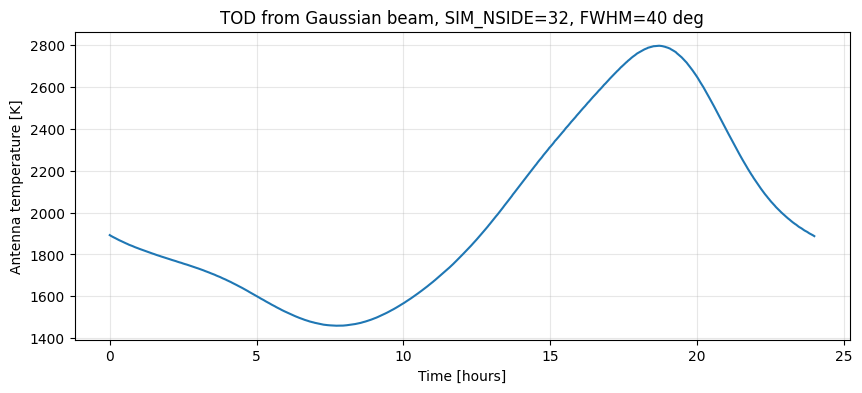

In [33]:
# ============================================================
# GENERATE TOD FROM RAW SKY + GAUSSIAN BEAM
# ============================================================
#
# Critical consistency choice:
# beam is peak-normalized, so generate_TOD_sky must normalize the beam
# if we want antenna temperatures in K rather than huge sum(beam * sky).

TOD = safe_generate_TOD_sky(
    beam_map=beam_map,
    sky_map=sky_map,
    LST_deg_list=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list=azimuth_deg_list,
    elevation_deg_list=elevation_deg_list,
    selfrot_deg_list=selfrot_deg_list,
    nside_hires=SIM_NSIDE,
    normalize_beam=NORMALIZE_BEAM_IN_TOD,
    truncate_frac_thres=TRUNC_FRAC,
)

TOD = np.asarray(TOD, dtype=float)
TOD = np.nan_to_num(TOD, nan=0.0, posinf=0.0, neginf=0.0)

print("TOD diagnostics")
print("---------------")
print("shape   :", TOD.shape)
print("min/max :", np.min(TOD), np.max(TOD))
print("mean/std:", np.mean(TOD), np.std(TOD))

plt.figure(figsize=(10, 4))
plt.plot(time_hours, TOD, lw=1.5)
plt.xlabel("Time [hours]")
plt.ylabel("Antenna temperature [K]")
plt.title(
    f"TOD from Gaussian beam, SIM_NSIDE={SIM_NSIDE}, "
    f"FWHM={GAUSS_FWHM_DEG:.0f} deg"
)
plt.grid(alpha=0.3)
plt.show()

100%|██████████| 2880/2880 [00:02<00:00, 1161.09it/s]


Circular Gaussian rotation sanity check
--------------------------------------
max abs difference       : 0.6659367332467809 K
mean abs difference      : 0.036315113482022966 K
relative norm difference : 3.7219047814006874e-05


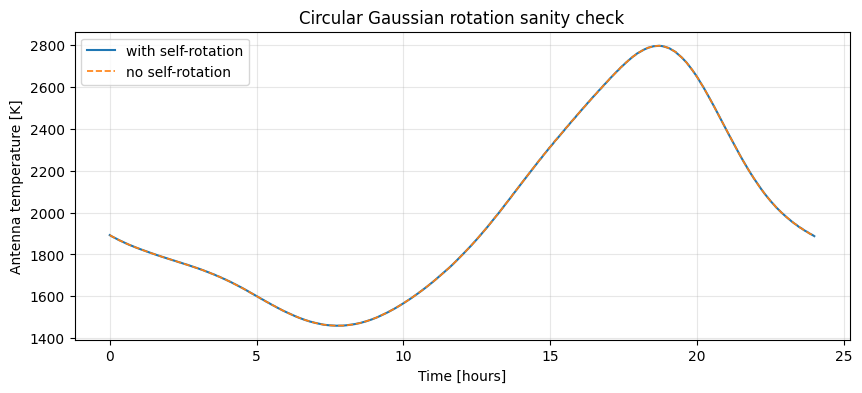

In [34]:
# ============================================================
# SANITY CHECK: CIRCULAR GAUSSIAN SHOULD NOT CARE ABOUT SELF-ROTATION
# ============================================================

selfrot_zero = np.zeros_like(selfrot_deg_list)

TOD_no_rot = safe_generate_TOD_sky(
    beam_map=beam_map,
    sky_map=sky_map,
    LST_deg_list=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list=azimuth_deg_list,
    elevation_deg_list=elevation_deg_list,
    selfrot_deg_list=selfrot_zero,
    nside_hires=SIM_NSIDE,
    normalize_beam=NORMALIZE_BEAM_IN_TOD,
    truncate_frac_thres=TRUNC_FRAC,
)

TOD_no_rot = np.asarray(TOD_no_rot, dtype=float)
TOD_no_rot = np.nan_to_num(TOD_no_rot, nan=0.0, posinf=0.0, neginf=0.0)

diff_rot = TOD - TOD_no_rot

print("Circular Gaussian rotation sanity check")
print("--------------------------------------")
print("max abs difference       :", np.max(np.abs(diff_rot)), "K")
print("mean abs difference      :", np.mean(np.abs(diff_rot)), "K")
print("relative norm difference :", np.linalg.norm(diff_rot) / np.linalg.norm(TOD))

plt.figure(figsize=(10, 4))
plt.plot(time_hours, TOD, label="with self-rotation", lw=1.5)
plt.plot(time_hours, TOD_no_rot, "--", label="no self-rotation", lw=1.2)
plt.xlabel("Time [hours]")
plt.ylabel("Antenna temperature [K]")
plt.title("Circular Gaussian rotation sanity check")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [35]:
# ============================================================
# INITIALIZE MAPMAKER
# ============================================================

mapper = HPW_mapmaking(
    beam_map=beam_map,
    LST_deg_list_group=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list_group=azimuth_deg_list,
    elevation_deg_list_group=elevation_deg_list,
    selfrot_deg_list_group=selfrot_deg_list,
    threshold=THRESHOLD,
    nside_hires=SIM_NSIDE,
    nside_target=MAP_NSIDE,
    beam_truncate_frac_thres=TRUNC_FRAC,
)

pix = get_selected_pixels_from_mapper(mapper)

print("Mapmaker diagnostics")
print("--------------------")
print("SIM_NSIDE       :", SIM_NSIDE)
print("MAP_NSIDE       :", MAP_NSIDE)
print("Total MAP pixels:", hp.nside2npix(MAP_NSIDE))
print("Selected pixels :", len(pix))
print("TOD samples     :", len(TOD))


Step 1: Generating the stacked abs(beam) map ... 



100%|██████████| 2880/2880 [00:02<00:00, 1384.94it/s]



Step 2: Selecting pixels above threshold sensitivity ... 

Number of data points: 2880
Number of selected pixels: 72


100%|██████████| 2880/2880 [00:02<00:00, 1391.94it/s]

Using mapper.pixel_indices for selected pixels.
Mapmaker diagnostics
--------------------
SIM_NSIDE       : 32
MAP_NSIDE       : 4
Total MAP pixels: 192
Selected pixels : 72
TOD samples     : 2880


In [37]:
# ============================================================
# EXTRACT GAUSSIAN-SMOOTHED TRUTH PATCH
# ============================================================
#
# This is the comparison truth.

truth_map = np.asarray(sky_gauss_map, dtype=float)

truth_nside = hp.npix2nside(len(truth_map))

if truth_nside != MAP_NSIDE:
    print(f"Changing truth map from NSIDE={truth_nside} to MAP_NSIDE={MAP_NSIDE}")
    truth_map = hp.ud_grade(
        truth_map,
        nside_out=MAP_NSIDE,
        power=0,
    )

truth_map = np.asarray(truth_map, dtype=float)
truth_map = np.nan_to_num(truth_map, nan=0.0, posinf=0.0, neginf=0.0)

truth_patch = truth_map[pix]

print("Truth patch diagnostics")
print("-----------------------")
print("truth map NSIDE :", hp.npix2nside(len(truth_map)))
print("selected pixels :", len(pix))
print("truth patch shape:", truth_patch.shape)
print("truth min/max   :", np.min(truth_patch), np.max(truth_patch))
print("truth mean/std  :", np.mean(truth_patch), np.std(truth_patch))

Truth patch diagnostics
-----------------------
truth map NSIDE : 4
selected pixels : 72
truth patch shape: (72,)
truth min/max   : 1509.7421659486495 5673.744909032673
truth mean/std  : 2483.479267294766 946.5379747463118


In [38]:
# ============================================================
# OPTIONAL FORWARD CONSISTENCY CHECK
# ============================================================
#
# This block tries to find the internal pointing/design matrix A if limTOD
# exposes it. If it cannot find it, the rest of the pipeline still runs.

forward_rel_err = np.nan

possible_A_names = [
    "A",
    "H",
    "pointing_matrix",
    "mapmaking_matrix",
    "operator",
    "M",
]

A = None
for name in possible_A_names:
    if hasattr(mapper, name):
        candidate = getattr(mapper, name)
        try:
            if candidate.shape[0] == len(TOD) and candidate.shape[1] == len(pix):
                A = candidate
                print(f"Using mapper.{name} as forward operator.")
                break
        except Exception:
            pass

if A is not None:
    forward_TOD = A @ truth_patch
    forward_TOD = np.asarray(forward_TOD, dtype=float)

    forward_rel_err = np.linalg.norm(forward_TOD - TOD) / np.linalg.norm(TOD)

    print("Forward consistency check")
    print("-------------------------")
    print("TOD min/max          :", np.min(TOD), np.max(TOD))
    print("A @ truth min/max    :", np.min(forward_TOD), np.max(forward_TOD))
    print("Forward rel err      :", forward_rel_err)

    plt.figure(figsize=(10, 4))
    plt.plot(time_hours, TOD, label="TOD from simulator", lw=1.5)
    plt.plot(time_hours, forward_TOD, "--", label="A @ Gaussian-smoothed truth", lw=1.2)
    plt.xlabel("Time [hours]")
    plt.ylabel("Temperature [K]")
    plt.title("Forward consistency check")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("Could not automatically find a forward operator on mapper.")
    print("Skipping A @ truth_patch check.")

Could not automatically find a forward operator on mapper.
Skipping A @ truth_patch check.


In [39]:
# ============================================================
# RUN MAPMAKER
# ============================================================

result = mapper(
    TOD_group=TOD,
    dtime=DT_SECONDS,
    regularization=REGULARIZATION,
    return_full_cov=False,
    use_high_pass=False,
)

sky_est_patch, sky_unc_patch = unpack_mapmaker_result(result)

sky_est_patch = np.asarray(sky_est_patch, dtype=float)
sky_est_patch = np.nan_to_num(sky_est_patch, nan=np.nan, posinf=np.nan, neginf=np.nan)

sky_unc_patch = np.asarray(sky_unc_patch, dtype=float)
sky_unc_patch = np.nan_to_num(sky_unc_patch, nan=np.nan, posinf=np.nan, neginf=np.nan)

print("Recovered patch diagnostics")
print("---------------------------")
print("sky_est_patch shape:", sky_est_patch.shape)
print("sky_unc_patch shape:", sky_unc_patch.shape)
print("rec min/max        :", np.nanmin(sky_est_patch), np.nanmax(sky_est_patch))
print("rec mean/std       :", np.nanmean(sky_est_patch), np.nanstd(sky_est_patch))
print("unc min/max        :", np.nanmin(sky_unc_patch), np.nanmax(sky_unc_patch))

Recovered patch diagnostics
---------------------------
sky_est_patch shape: (72,)
sky_unc_patch shape: (72,)
rec min/max        : -203.2752140253349 798.149491555963
rec mean/std       : 188.58022998561682 213.2540136144398
unc min/max        : 15.099189375619623 43.2736546074204


Reconstruction metrics against Gaussian-smoothed truth
-----------------------------------------------------
SIM_NSIDE       : 32
MAP_NSIDE       : 4
Gaussian FWHM   : 40.00 deg
Selected pixels : 72
Good pixels     : 72
TOD samples     : 2880
Forward rel err : nan

Truth min/max   : 1509.742166, 5673.744909
Truth mean/std  : 2483.479267, 946.537975
Rec min/max     : -203.275214, 798.149492
Rec mean/std    : 188.580230, 213.254014

RMSE [K]        : 2498.272115
Relative RMSE   : 1.005957e+00
Bias [K]        : -2294.899037
Correlation     : -0.082710


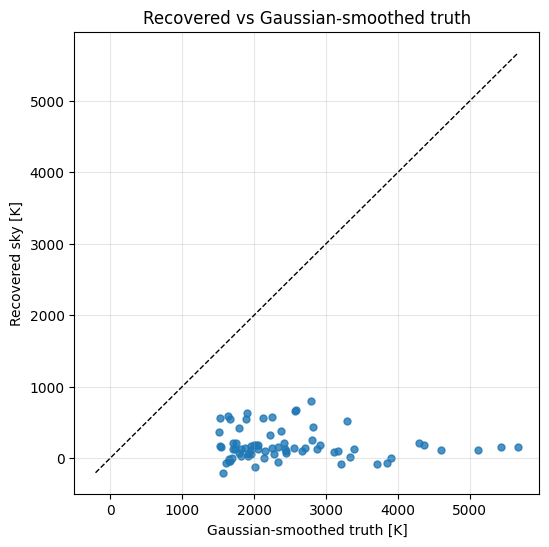

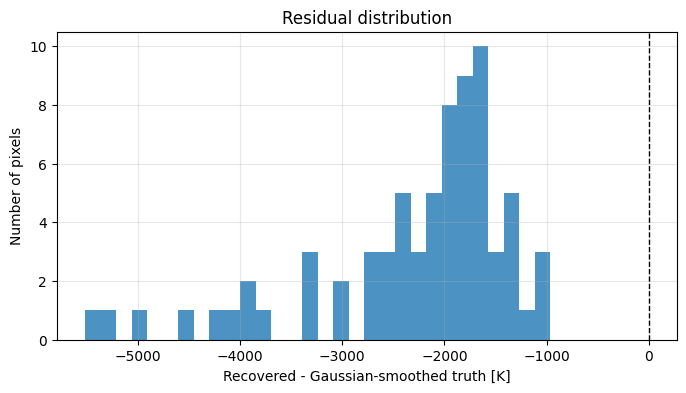

In [40]:
# ============================================================
# RECONSTRUCTION METRICS AGAINST GAUSSIAN-SMOOTHED TRUTH
# ============================================================

good = (
    np.isfinite(truth_patch)
    & np.isfinite(sky_est_patch)
)

# Only require uncertainty to be finite if the mapmaker actually returned it.
if np.any(np.isfinite(sky_unc_patch)):
    good = good & np.isfinite(sky_unc_patch)

truth_patch_good = truth_patch[good]
sky_est_patch_good = sky_est_patch[good]
pix_good = pix[good]

if np.any(np.isfinite(sky_unc_patch)):
    sky_unc_patch_good = sky_unc_patch[good]
else:
    sky_unc_patch_good = np.full_like(sky_est_patch_good, np.nan, dtype=float)

residual_patch_good = sky_est_patch_good - truth_patch_good

rmse = np.sqrt(np.mean(residual_patch_good ** 2))
bias = np.mean(residual_patch_good)
rel_rmse = rmse / np.mean(np.abs(truth_patch_good))

if np.std(sky_est_patch_good) > 0 and np.std(truth_patch_good) > 0:
    corr = np.corrcoef(truth_patch_good, sky_est_patch_good)[0, 1]
else:
    corr = np.nan

print("Reconstruction metrics against Gaussian-smoothed truth")
print("-----------------------------------------------------")
print(f"SIM_NSIDE       : {SIM_NSIDE}")
print(f"MAP_NSIDE       : {MAP_NSIDE}")
print(f"Gaussian FWHM   : {GAUSS_FWHM_DEG:.2f} deg")
print(f"Selected pixels : {len(pix)}")
print(f"Good pixels     : {len(pix_good)}")
print(f"TOD samples     : {len(TOD)}")
print(f"Forward rel err : {forward_rel_err}")
print()
print(f"Truth min/max   : {np.min(truth_patch_good):.6f}, {np.max(truth_patch_good):.6f}")
print(f"Truth mean/std  : {np.mean(truth_patch_good):.6f}, {np.std(truth_patch_good):.6f}")
print(f"Rec min/max     : {np.min(sky_est_patch_good):.6f}, {np.max(sky_est_patch_good):.6f}")
print(f"Rec mean/std    : {np.mean(sky_est_patch_good):.6f}, {np.std(sky_est_patch_good):.6f}")
print()
print(f"RMSE [K]        : {rmse:.6f}")
print(f"Relative RMSE   : {rel_rmse:.6e}")
print(f"Bias [K]        : {bias:.6f}")
print(f"Correlation     : {corr:.6f}")

plt.figure(figsize=(6, 6))
plt.scatter(truth_patch_good, sky_est_patch_good, s=25, alpha=0.8)

lo = min(np.min(truth_patch_good), np.min(sky_est_patch_good))
hi = max(np.max(truth_patch_good), np.max(sky_est_patch_good))

plt.plot([lo, hi], [lo, hi], "k--", lw=1)
plt.xlabel("Gaussian-smoothed truth [K]")
plt.ylabel("Recovered sky [K]")
plt.title("Recovered vs Gaussian-smoothed truth")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(residual_patch_good, bins=30, alpha=0.8)
plt.axvline(0.0, color="k", linestyle="--", linewidth=1)
plt.xlabel("Recovered - Gaussian-smoothed truth [K]")
plt.ylabel("Number of pixels")
plt.title("Residual distribution")
plt.grid(alpha=0.3)
plt.show()

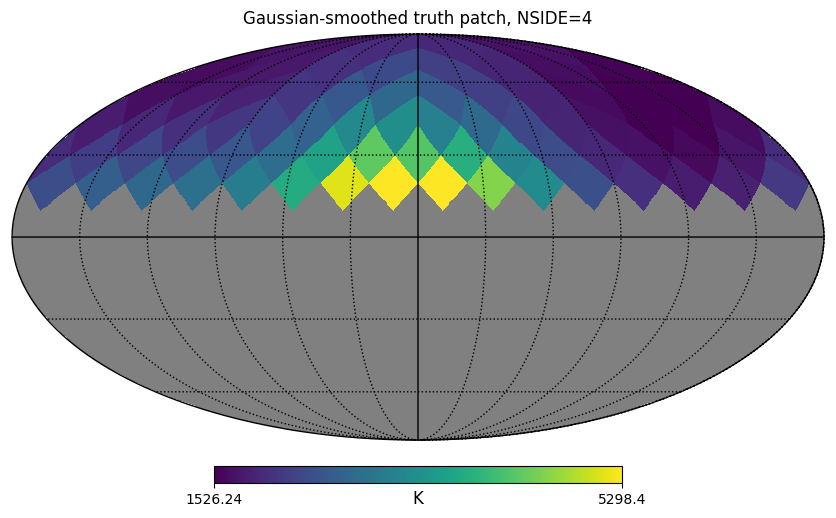

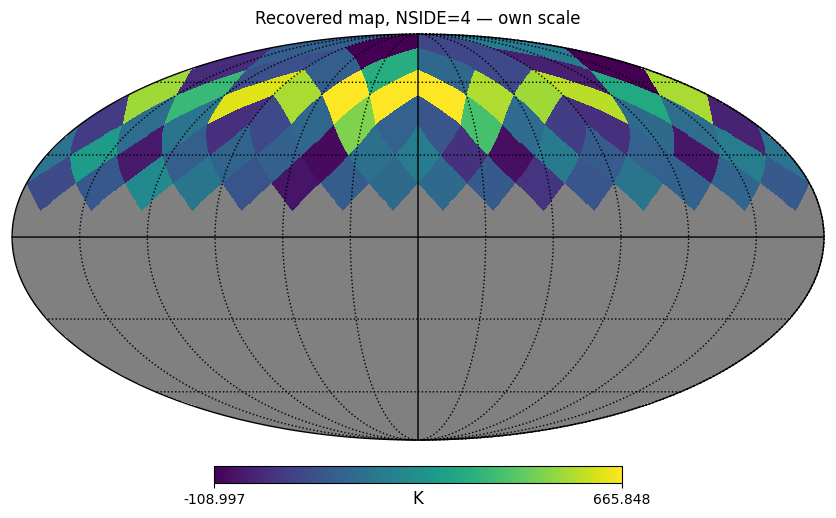

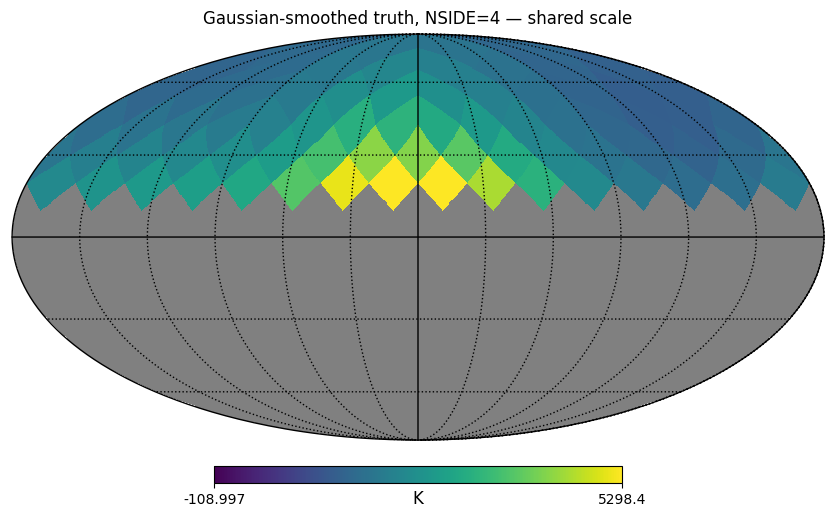

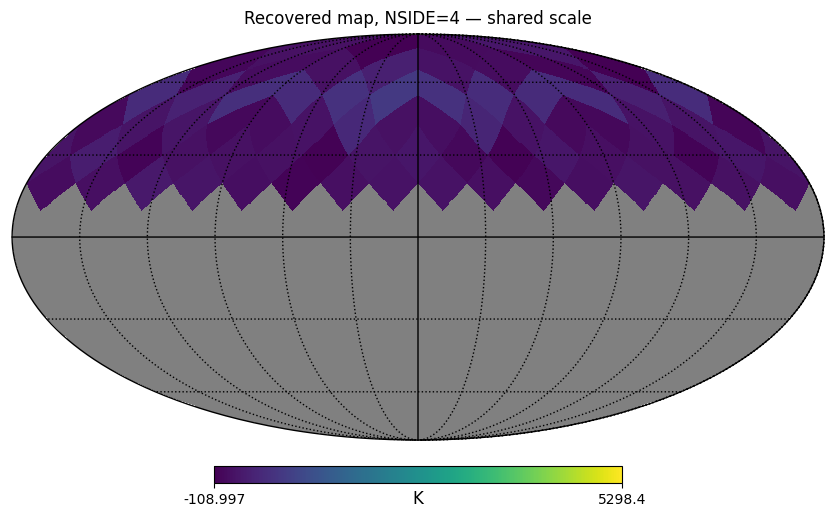

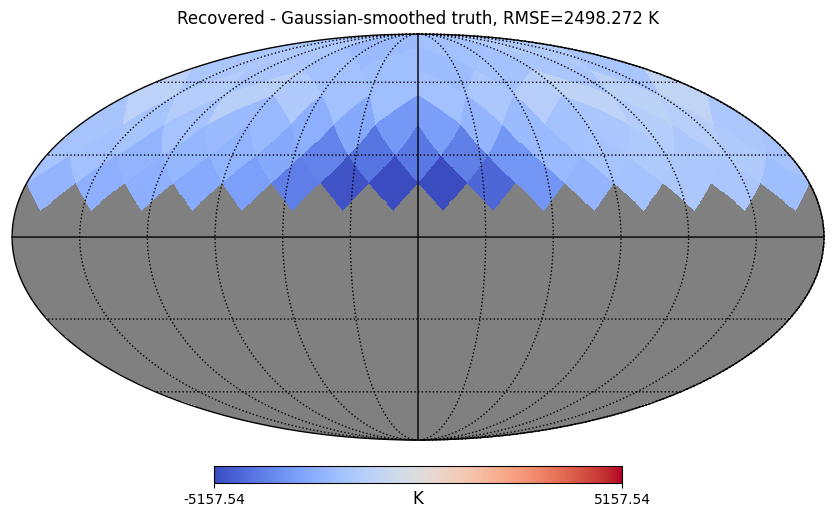

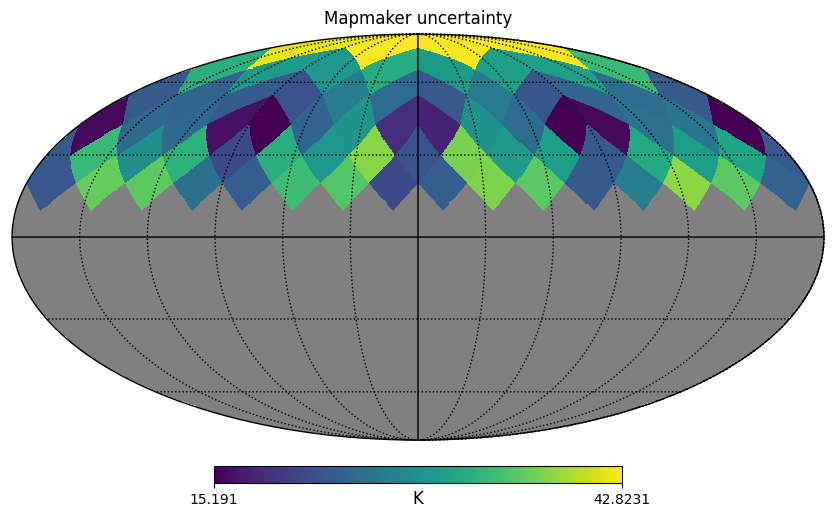

In [41]:
# ============================================================
# PLOT TRUTH / RECOVERED / RESIDUAL MAPS
# ============================================================

truth_full = patch_to_full_map(
    pix=pix_good,
    values=truth_patch_good,
    nside=MAP_NSIDE,
)

recovered_full = patch_to_full_map(
    pix=pix_good,
    values=sky_est_patch_good,
    nside=MAP_NSIDE,
)

residual_full = patch_to_full_map(
    pix=pix_good,
    values=residual_patch_good,
    nside=MAP_NSIDE,
)

unc_full = patch_to_full_map(
    pix=pix_good,
    values=sky_unc_patch_good,
    nside=MAP_NSIDE,
)

truth_vmin = np.nanpercentile(truth_patch_good, 2)
truth_vmax = np.nanpercentile(truth_patch_good, 98)

rec_vmin = np.nanpercentile(sky_est_patch_good, 2)
rec_vmax = np.nanpercentile(sky_est_patch_good, 98)

shared_vmin = min(truth_vmin, rec_vmin)
shared_vmax = max(truth_vmax, rec_vmax)

res_lim = np.nanpercentile(np.abs(residual_patch_good), 98)

if np.any(np.isfinite(sky_unc_patch_good)):
    unc_vmin = np.nanpercentile(sky_unc_patch_good, 2)
    unc_vmax = np.nanpercentile(sky_unc_patch_good, 98)
else:
    unc_vmin = None
    unc_vmax = None

hp.mollview(
    truth_full,
    title=f"Gaussian-smoothed truth patch, NSIDE={MAP_NSIDE}",
    unit="K",
    min=truth_vmin,
    max=truth_vmax,
    cmap="viridis",
)
hp.graticule()
plt.show()

hp.mollview(
    recovered_full,
    title=f"Recovered map, NSIDE={MAP_NSIDE} — own scale",
    unit="K",
    min=rec_vmin,
    max=rec_vmax,
    cmap="viridis",
)
hp.graticule()
plt.show()

hp.mollview(
    truth_full,
    title=f"Gaussian-smoothed truth, NSIDE={MAP_NSIDE} — shared scale",
    unit="K",
    min=shared_vmin,
    max=shared_vmax,
    cmap="viridis",
)
hp.graticule()
plt.show()

hp.mollview(
    recovered_full,
    title=f"Recovered map, NSIDE={MAP_NSIDE} — shared scale",
    unit="K",
    min=shared_vmin,
    max=shared_vmax,
    cmap="viridis",
)
hp.graticule()
plt.show()

hp.mollview(
    residual_full,
    title=f"Recovered - Gaussian-smoothed truth, RMSE={rmse:.3f} K",
    unit="K",
    min=-res_lim,
    max=res_lim,
    cmap="coolwarm",
)
hp.graticule()
plt.show()

if np.any(np.isfinite(sky_unc_patch_good)):
    hp.mollview(
        unc_full,
        title="Mapmaker uncertainty",
        unit="K",
        min=unc_vmin,
        max=unc_vmax,
        cmap="viridis",
    )
    hp.graticule()
    plt.show()
else:
    print("No finite uncertainty map returned, so uncertainty plot skipped.")

In [42]:
# ============================================================
# END-TO-END GAUSSIAN TOD + MAP RECOVERY
# 24 hr run, Jodrell Bank, SIM_NSIDE=32, MAP_NSIDE=4 and 8
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import inspect

from limTOD import generate_LSTs_deg, generate_TOD_sky
from limTOD import GDSM_sky_model
from limTOD import HPW_mapmaking

In [43]:
# ============================================================
# CONFIG
# ============================================================

FREQ_MHZ = 70.0

SIM_NSIDE = 32
MAP_NSIDE_LIST = [4, 8]

GAUSS_FWHM_DEG = 40.0

OBS_HOURS = 24.0
DT_SECONDS = 120.0

# Jodrell Bank / Lovell telescope approximate coordinates
ANT_LAT = 53.23625
ANT_LON = -2.30714
ANT_HEIGHT_M = 80.0

# Zenith drift scan
AZIMUTH_DEG = 0.0
ELEVATION_DEG = 90.0

# Rotating beam: 360 degrees per hour
# For a perfectly symmetric Gaussian, this should not change the physics,
# but we include it because this is the scan strategy you asked for.
ROTATION_PERIOD_HOURS = 1.0

# Consistency settings
NORMALIZE_BEAM_IN_TOD = True
THRESHOLD = 0.05
BEAM_TRUNCATE_FRAC = THRESHOLD
REGULARIZATION = 1e-6

print("Configuration")
print("-------------")
print(f"Frequency              : {FREQ_MHZ} MHz")
print(f"Simulation NSIDE       : {SIM_NSIDE}")
print(f"Map NSIDEs             : {MAP_NSIDE_LIST}")
print(f"Gaussian FWHM          : {GAUSS_FWHM_DEG} deg")
print(f"Observation length     : {OBS_HOURS} hr")
print(f"Time step              : {DT_SECONDS} s")
print(f"Latitude               : {ANT_LAT} deg")
print(f"Longitude              : {ANT_LON} deg")
print(f"Elevation              : {ELEVATION_DEG} deg")
print(f"Rotation period        : {ROTATION_PERIOD_HOURS} hr")
print(f"Normalize beam in TOD  : {NORMALIZE_BEAM_IN_TOD}")
print(f"Mapmaker threshold     : {THRESHOLD}")
print(f"Beam truncate fraction : {BEAM_TRUNCATE_FRAC}")
print(f"Regularization         : {REGULARIZATION}")

Configuration
-------------
Frequency              : 70.0 MHz
Simulation NSIDE       : 32
Map NSIDEs             : [4, 8]
Gaussian FWHM          : 40.0 deg
Observation length     : 24.0 hr
Time step              : 120.0 s
Latitude               : 53.23625 deg
Longitude              : -2.30714 deg
Elevation              : 90.0 deg
Rotation period        : 1.0 hr
Normalize beam in TOD  : True
Mapmaker threshold     : 0.05
Beam truncate fraction : 0.05
Regularization         : 1e-06


In [44]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def make_symmetric_gaussian_beam(nside, fwhm_deg):
    """
    Makes a symmetric Gaussian beam centred on the north pole of the beam frame.
    The beam is peak-normalised to 1.
    """
    npix = hp.nside2npix(nside)
    pix = np.arange(npix)

    theta, phi = hp.pix2ang(nside, pix)

    fwhm_rad = np.deg2rad(fwhm_deg)
    sigma_rad = fwhm_rad / np.sqrt(8.0 * np.log(2.0))

    beam = np.exp(-0.5 * (theta / sigma_rad) ** 2)
    beam = np.nan_to_num(beam, nan=0.0, posinf=0.0, neginf=0.0)

    beam /= np.max(beam)

    return beam


def safe_generate_TOD_sky(
    beam_map,
    sky_map,
    LST_deg_list,
    lat_deg,
    azimuth_deg_list,
    elevation_deg_list,
    selfrot_deg_list,
    nside_hires,
    normalize_beam=True,
    truncate_frac_thres=None,
):
    """
    Calls generate_TOD_sky while handling small keyword differences
    between limTOD versions.
    """
    sig = inspect.signature(generate_TOD_sky)

    kwargs = dict(
        beam_map=beam_map,
        sky_map=sky_map,
        LST_deg_list=LST_deg_list,
        azimuth_deg_list=azimuth_deg_list,
        elevation_deg_list=elevation_deg_list,
        selfrot_deg_list=selfrot_deg_list,
        nside_hires=nside_hires,
        normalize_beam=normalize_beam,
    )

    if "lat_deg" in sig.parameters:
        kwargs["lat_deg"] = lat_deg
    elif "lat" in sig.parameters:
        kwargs["lat"] = lat_deg
    else:
        raise TypeError("generate_TOD_sky does not seem to accept lat or lat_deg.")

    if "truncate_frac_thres" in sig.parameters and truncate_frac_thres is not None:
        kwargs["truncate_frac_thres"] = truncate_frac_thres

    return generate_TOD_sky(**kwargs)


def get_selected_pixels_from_mapper(mapper):
    """
    Finds the selected pixel list from common mapper attribute names.
    """
    names = [
        "pixel_indices",
        "pix",
        "selected_pixels",
        "selected_pix",
        "pix_selected",
        "observed_pixels",
        "nonzero_pix",
    ]

    for name in names:
        if hasattr(mapper, name):
            pix = np.asarray(getattr(mapper, name), dtype=int)
            if pix.ndim == 1 and len(pix) > 0:
                print(f"Selected pixels found from mapper.{name}")
                return pix

    print("Available mapper attributes:")
    print([x for x in dir(mapper) if "pix" in x.lower() or "pixel" in x.lower()])
    raise AttributeError("Could not find selected pixels automatically.")


def unpack_mapmaker_result(result):
    """
    Handles different possible return formats from HPW_mapmaking.
    """
    if isinstance(result, tuple):
        sky_est_patch = np.asarray(result[0], dtype=float)

        if len(result) > 1:
            sky_unc_patch = np.asarray(result[1], dtype=float)
        else:
            sky_unc_patch = np.full_like(sky_est_patch, np.nan)

    else:
        sky_est_patch = np.asarray(result, dtype=float)
        sky_unc_patch = np.full_like(sky_est_patch, np.nan)

    return sky_est_patch, sky_unc_patch


def patch_to_full_map(pix, values, nside):
    """
    Puts recovered patch pixels into a full HEALPix map.
    Unrecovered pixels are grey / unseen.
    """
    full_map = np.full(hp.nside2npix(nside), hp.UNSEEN, dtype=float)
    full_map[np.asarray(pix, dtype=int)] = np.asarray(values, dtype=float)
    return full_map


def print_array_stats(name, arr):
    arr = np.asarray(arr, dtype=float)
    finite = np.isfinite(arr)

    print(name)
    print("-" * len(name))
    print("shape    :", arr.shape)
    print("finite   :", np.sum(finite), "/", arr.size)
    print("min/max  :", np.nanmin(arr[finite]), np.nanmax(arr[finite]))
    print("mean/std :", np.nanmean(arr[finite]), np.nanstd(arr[finite]))
    print()

Observation setup
-----------------
Number of samples : 720
LST min/max       : 0.07002649187575508 359.56865745791487
Rotation min/max  : 0.0 348.0


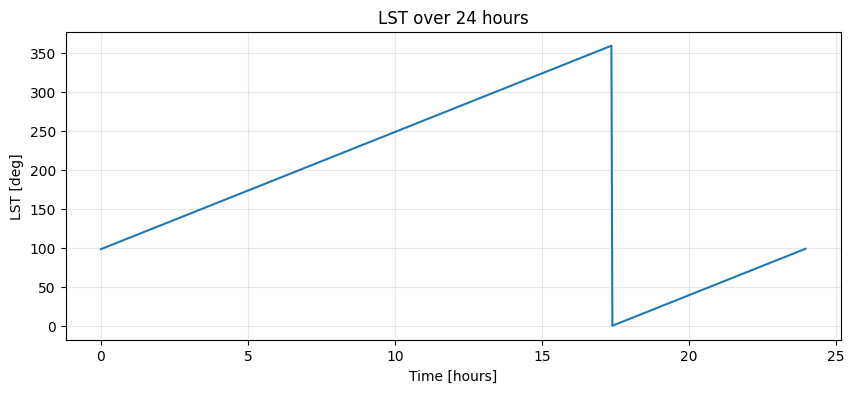

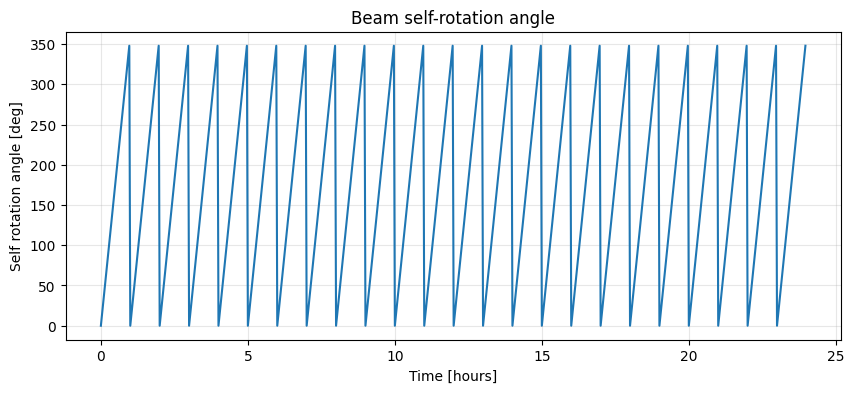

In [45]:
# ============================================================
# TIME, LST, POINTING, ROTATION
# ============================================================

N_TIME = int(OBS_HOURS * 3600.0 / DT_SECONDS)

time_seconds = np.arange(N_TIME) * DT_SECONDS
time_hours = time_seconds / 3600.0

LST_deg_list = generate_LSTs_deg(
    ant_latitude_deg=ANT_LAT,
    ant_longitude_deg=ANT_LON,
    ant_height_m=ANT_HEIGHT_M,
    time_list=time_seconds,
    start_time_utc="2026-01-01T00:00:00",
)

LST_deg_list = np.asarray(LST_deg_list, dtype=float)

azimuth_deg_list = np.full(N_TIME, AZIMUTH_DEG, dtype=float)
elevation_deg_list = np.full(N_TIME, ELEVATION_DEG, dtype=float)

rotation_period_seconds = ROTATION_PERIOD_HOURS * 3600.0
selfrot_deg_list = (360.0 * time_seconds / rotation_period_seconds) % 360.0

print("Observation setup")
print("-----------------")
print("Number of samples :", N_TIME)
print("LST min/max       :", np.min(LST_deg_list), np.max(LST_deg_list))
print("Rotation min/max  :", np.min(selfrot_deg_list), np.max(selfrot_deg_list))

plt.figure(figsize=(10, 4))
plt.plot(time_hours, LST_deg_list)
plt.xlabel("Time [hours]")
plt.ylabel("LST [deg]")
plt.title("LST over 24 hours")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_hours, selfrot_deg_list)
plt.xlabel("Time [hours]")
plt.ylabel("Self rotation angle [deg]")
plt.title("Beam self-rotation angle")
plt.grid(alpha=0.3)
plt.show()

Input GDSM sky
--------------
shape    : (12288,)
finite   : 12288 / 12288
min/max  : -2736.16162109375 73141.6484375
mean/std : 2757.6338613828025 2209.2382783614494



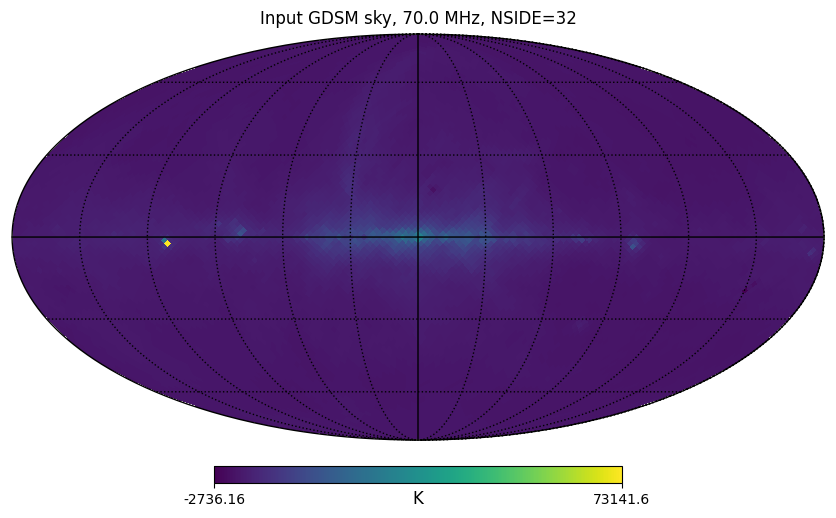

In [46]:
# ============================================================
# SKY AT SIMULATION NSIDE
# ============================================================

sky_map = GDSM_sky_model(
    freq=FREQ_MHZ,
    nside=SIM_NSIDE,
)

sky_map = np.asarray(sky_map, dtype=float)
sky_map = np.nan_to_num(sky_map, nan=0.0, posinf=0.0, neginf=0.0)

print_array_stats("Input GDSM sky", sky_map)

hp.mollview(
    sky_map,
    title=f"Input GDSM sky, {FREQ_MHZ:.1f} MHz, NSIDE={SIM_NSIDE}",
    unit="K",
    cmap="viridis",
)
hp.graticule()
plt.show()

Symmetric Gaussian beam
-----------------------
shape    : (12288,)
finite   : 12288 / 12288
min/max  : 1.0295745688916673e-24 1.0
mean/std : 0.04281341942858549 0.1412625069956807

Beam checks
-----------
Beam peak: 1.0
Beam sum over pixels: 526.0912979384585
Pixel-area weighted beam integral [sr]: 0.5380092958076108



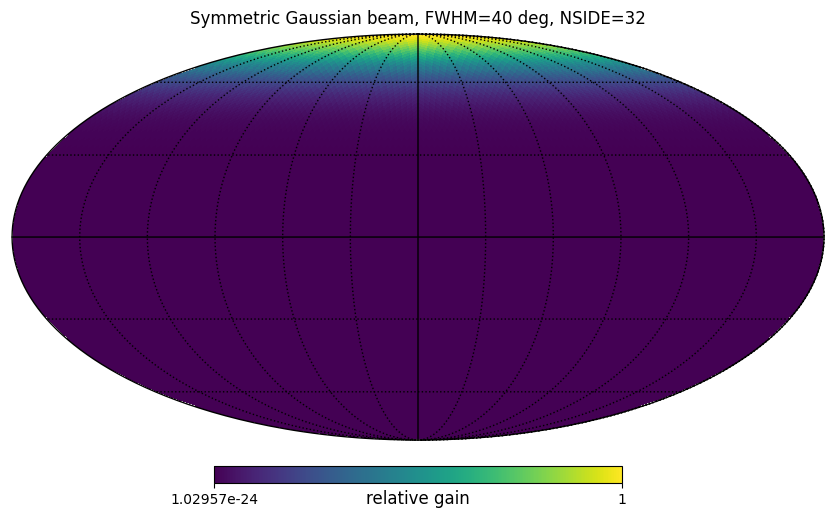

In [47]:
# ============================================================
# SYMMETRIC GAUSSIAN BEAM AT SIMULATION NSIDE
# ============================================================

beam_map = make_symmetric_gaussian_beam(
    nside=SIM_NSIDE,
    fwhm_deg=GAUSS_FWHM_DEG,
)

print_array_stats("Symmetric Gaussian beam", beam_map)

print("Beam checks")
print("-----------")
print("Beam peak:", np.max(beam_map))
print("Beam sum over pixels:", np.sum(beam_map))
print("Pixel-area weighted beam integral [sr]:", np.sum(beam_map) * hp.nside2pixarea(SIM_NSIDE))
print()

hp.mollview(
    beam_map,
    title=f"Symmetric Gaussian beam, FWHM={GAUSS_FWHM_DEG:.0f} deg, NSIDE={SIM_NSIDE}",
    unit="relative gain",
    cmap="viridis",
)
hp.graticule()
plt.show()

100%|██████████| 720/720 [00:00<00:00, 1073.96it/s]

Generated TOD
-------------
shape    : (720,)
finite   : 720 / 720
min/max  : 1459.499301730445 2797.529358592147
mean/std : 1989.1446493002372 426.58409680307204



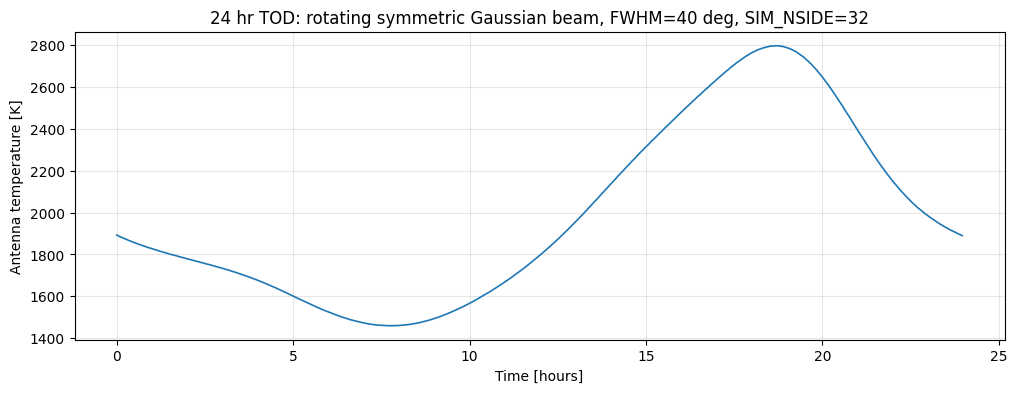

In [48]:
# ============================================================
# GENERATE TOD
# ============================================================

TOD = safe_generate_TOD_sky(
    beam_map=beam_map,
    sky_map=sky_map,
    LST_deg_list=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list=azimuth_deg_list,
    elevation_deg_list=elevation_deg_list,
    selfrot_deg_list=selfrot_deg_list,
    nside_hires=SIM_NSIDE,
    normalize_beam=NORMALIZE_BEAM_IN_TOD,
    truncate_frac_thres=BEAM_TRUNCATE_FRAC,
)

TOD = np.asarray(TOD, dtype=float)
TOD = np.nan_to_num(TOD, nan=0.0, posinf=0.0, neginf=0.0)

print_array_stats("Generated TOD", TOD)

plt.figure(figsize=(12, 4))
plt.plot(time_hours, TOD, lw=1.2)
plt.xlabel("Time [hours]")
plt.ylabel("Antenna temperature [K]")
plt.title(
    f"24 hr TOD: rotating symmetric Gaussian beam, "
    f"FWHM={GAUSS_FWHM_DEG:.0f} deg, SIM_NSIDE={SIM_NSIDE}"
)
plt.grid(alpha=0.3)
plt.show()

100%|██████████| 720/720 [00:00<00:00, 1087.31it/s]


Rotation sanity check
---------------------
max abs difference [K] : 0.457120840359039
mean abs difference [K]: 0.03786178304667784
relative difference    : 3.7100515799733045e-05


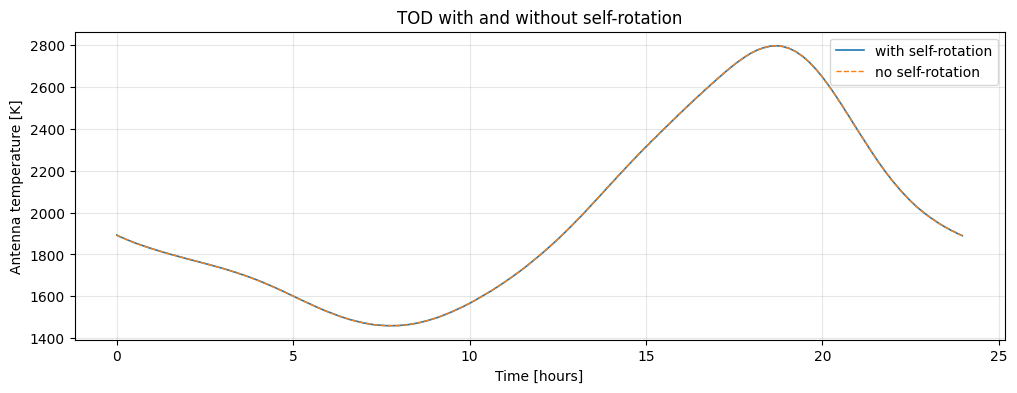

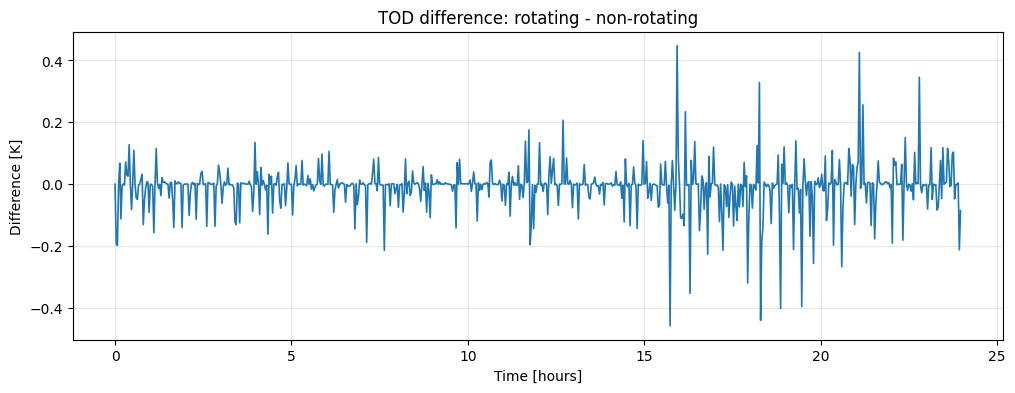

In [49]:
# ============================================================
# SANITY CHECK: ROTATION SHOULD NOT MATTER MUCH FOR SYMMETRIC GAUSSIAN
# ============================================================

selfrot_zero = np.zeros_like(selfrot_deg_list)

TOD_no_rotation = safe_generate_TOD_sky(
    beam_map=beam_map,
    sky_map=sky_map,
    LST_deg_list=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list=azimuth_deg_list,
    elevation_deg_list=elevation_deg_list,
    selfrot_deg_list=selfrot_zero,
    nside_hires=SIM_NSIDE,
    normalize_beam=NORMALIZE_BEAM_IN_TOD,
    truncate_frac_thres=BEAM_TRUNCATE_FRAC,
)

TOD_no_rotation = np.asarray(TOD_no_rotation, dtype=float)
TOD_no_rotation = np.nan_to_num(TOD_no_rotation, nan=0.0, posinf=0.0, neginf=0.0)

rotation_difference = TOD - TOD_no_rotation

print("Rotation sanity check")
print("---------------------")
print("max abs difference [K] :", np.max(np.abs(rotation_difference)))
print("mean abs difference [K]:", np.mean(np.abs(rotation_difference)))
print("relative difference    :", np.linalg.norm(rotation_difference) / np.linalg.norm(TOD))

plt.figure(figsize=(12, 4))
plt.plot(time_hours, TOD, label="with self-rotation", lw=1.2)
plt.plot(time_hours, TOD_no_rotation, "--", label="no self-rotation", lw=1.0)
plt.xlabel("Time [hours]")
plt.ylabel("Antenna temperature [K]")
plt.title("TOD with and without self-rotation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(time_hours, rotation_difference, lw=1.2)
plt.xlabel("Time [hours]")
plt.ylabel("Difference [K]")
plt.title("TOD difference: rotating - non-rotating")
plt.grid(alpha=0.3)
plt.show()

In [50]:
# ============================================================
# MAPMAKING FUNCTION
# ============================================================

def recover_map_for_nside(map_nside):
    print("\n" + "=" * 70)
    print(f"RECOVERING MAP AT NSIDE={map_nside}")
    print("=" * 70)

    mapper = HPW_mapmaking(
        beam_map=beam_map,
        LST_deg_list_group=LST_deg_list,
        lat_deg=ANT_LAT,
        azimuth_deg_list_group=azimuth_deg_list,
        elevation_deg_list_group=elevation_deg_list,
        selfrot_deg_list_group=selfrot_deg_list,
        threshold=THRESHOLD,
        nside_hires=SIM_NSIDE,
        nside_target=map_nside,
        beam_truncate_frac_thres=BEAM_TRUNCATE_FRAC,
    )

    pix = get_selected_pixels_from_mapper(mapper)

    print("Mapmaker setup")
    print("--------------")
    print("SIM_NSIDE       :", SIM_NSIDE)
    print("MAP_NSIDE       :", map_nside)
    print("Total map pixels:", hp.nside2npix(map_nside))
    print("Recovered pixels:", len(pix))
    print("TOD samples     :", len(TOD))

    result = mapper(
        TOD_group=TOD,
        dtime=DT_SECONDS,
        regularization=REGULARIZATION,
        return_full_cov=False,
        use_high_pass=False,
    )

    sky_est_patch, sky_unc_patch = unpack_mapmaker_result(result)

    sky_est_patch = np.asarray(sky_est_patch, dtype=float)
    sky_unc_patch = np.asarray(sky_unc_patch, dtype=float)

    good = np.isfinite(sky_est_patch)
    pix_good = pix[good]
    sky_est_good = sky_est_patch[good]

    recovered_full = patch_to_full_map(
        pix=pix_good,
        values=sky_est_good,
        nside=map_nside,
    )

    print_array_stats(f"Recovered sky patch, NSIDE={map_nside}", sky_est_good)

    vmin = np.nanpercentile(sky_est_good, 2)
    vmax = np.nanpercentile(sky_est_good, 98)

    hp.mollview(
        recovered_full,
        title=f"Recovered map only, NSIDE={map_nside}",
        unit="K",
        min=vmin,
        max=vmax,
        cmap="viridis",
    )
    hp.graticule()
    plt.show()

    return {
        "map_nside": map_nside,
        "mapper": mapper,
        "pix": pix,
        "pix_good": pix_good,
        "sky_est_patch": sky_est_patch,
        "sky_est_good": sky_est_good,
        "sky_unc_patch": sky_unc_patch,
        "recovered_full": recovered_full,
    }


RECOVERING MAP AT NSIDE=4

Step 1: Generating the stacked abs(beam) map ... 



100%|██████████| 720/720 [00:00<00:00, 1312.20it/s]



Step 2: Selecting pixels above threshold sensitivity ... 

Number of data points: 720
Number of selected pixels: 72


100%|██████████| 720/720 [00:00<00:00, 943.46it/s] 


Selected pixels found from mapper.pixel_indices
Mapmaker setup
--------------
SIM_NSIDE       : 32
MAP_NSIDE       : 4
Total map pixels: 192
Recovered pixels: 72
TOD samples     : 720
Recovered sky patch, NSIDE=4
----------------------------
shape    : (72,)
finite   : 72 / 72
min/max  : -241.27078033119523 729.0572456215262
mean/std : 201.46599298392928 195.273417368638



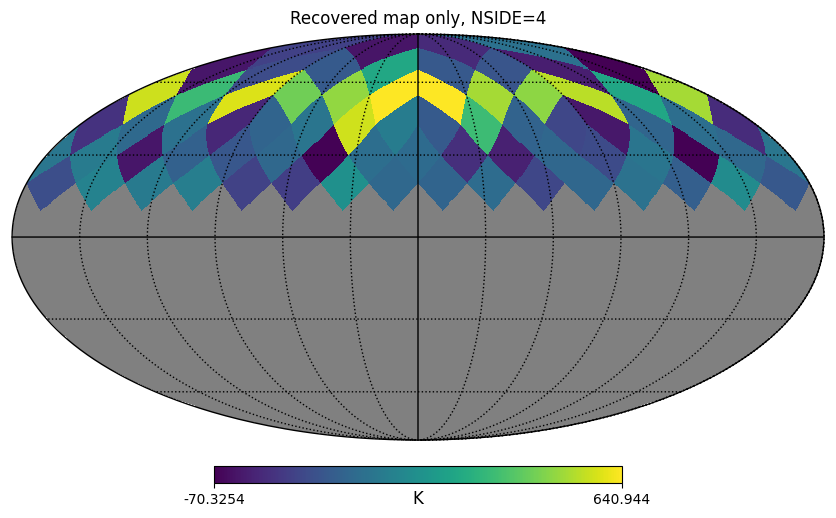


RECOVERING MAP AT NSIDE=8

Step 1: Generating the stacked abs(beam) map ... 



100%|██████████| 720/720 [00:00<00:00, 1262.80it/s]



Step 2: Selecting pixels above threshold sensitivity ... 

Number of data points: 720
Number of selected pixels: 304


100%|██████████| 720/720 [00:00<00:00, 1340.34it/s]


Selected pixels found from mapper.pixel_indices
Mapmaker setup
--------------
SIM_NSIDE       : 32
MAP_NSIDE       : 8
Total map pixels: 768
Recovered pixels: 304
TOD samples     : 720
Recovered sky patch, NSIDE=8
----------------------------
shape    : (304,)
finite   : 304 / 304
min/max  : -609.6031101603309 596.3290110303509
mean/std : 13.551261991735444 151.54649962376732



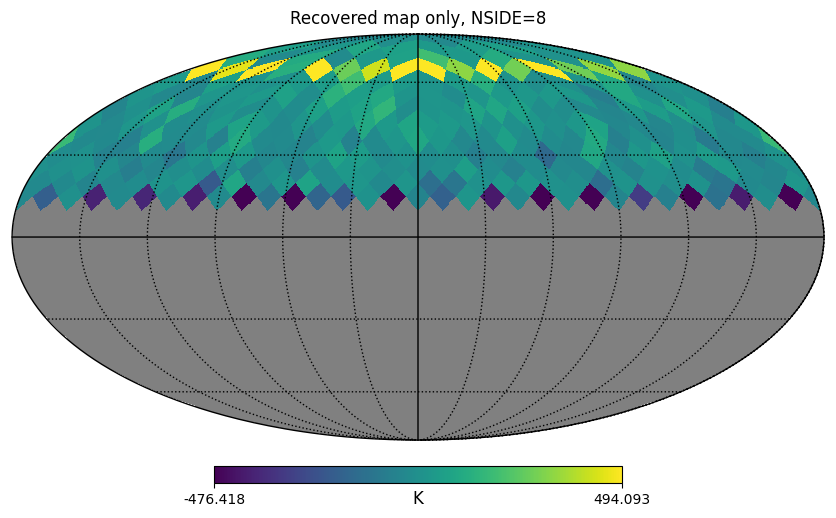

In [20]:
# ============================================================
# RECOVER MAPS AT NSIDE 4 AND NSIDE 8
# ============================================================

results = {}

for map_nside in MAP_NSIDE_LIST:
    results[map_nside] = recover_map_for_nside(map_nside)

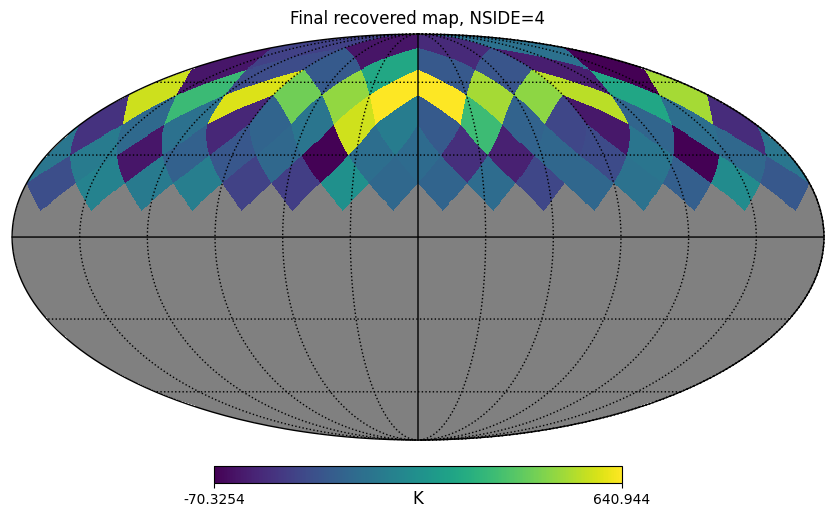

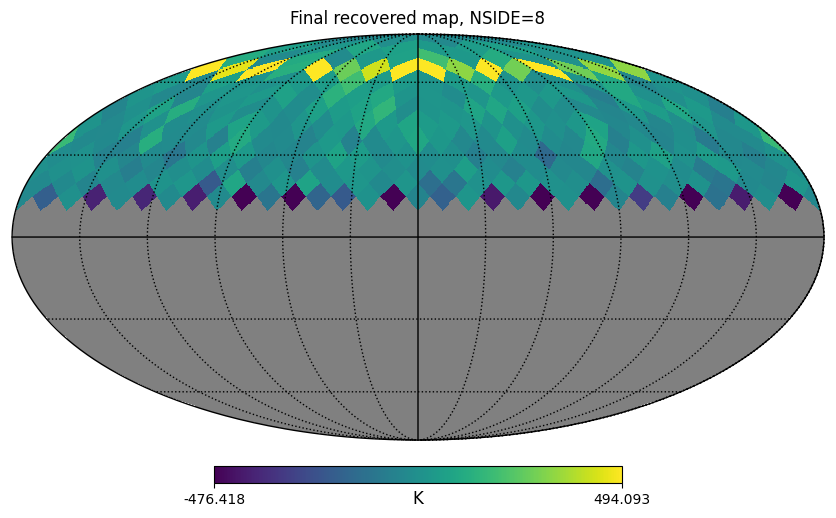

In [51]:
# ============================================================
# OPTIONAL: PLOT NSIDE 4 AND NSIDE 8 RECOVERED MAPS AGAIN
# ============================================================

for map_nside, res in results.items():
    sky_est_good = res["sky_est_good"]
    recovered_full = res["recovered_full"]

    vmin = np.nanpercentile(sky_est_good, 2)
    vmax = np.nanpercentile(sky_est_good, 98)

    hp.mollview(
        recovered_full,
        title=f"Final recovered map, NSIDE={map_nside}",
        unit="K",
        min=vmin,
        max=vmax,
        cmap="viridis",
    )
    hp.graticule()
    plt.show()